# Plot CORSIKA data 

## version: 2026-05-14

thinned file from `/data/sim/IceCubeUpgrade/CosmicRay/Radio/coreas/data/continuous/star-pattern`

# parameter setting

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy import signal, fft, constants, optimize
from io import StringIO
import os
from corsikaio import CorsikaParticleFile
import random
from functions import *
import joblib
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit

#=====================================
# file paths 
#=====================================

flong = fp_long(primary, energy, sin2theta, runnum)
flist = fp_list(primary, energy, sin2theta, runnum)
finp = fp_inp(primary, energy, sin2theta, runnum)
fNmu = fp_Nmu(primary, energy, sin2theta, runnum)
fNe = fp_Ne(primary, energy, sin2theta, runnum)
fRadE = fp_RadE(primary, energy, sin2theta)

#=====================================
# load data
#=====================================

# antenna positions
xypos = lambda runnum: pd.read_csv(flist, sep=r"\s+",header=None)
ant_x = lambda xpos: xpos.astype(float)/1e2 # x position in m
ant_y =  lambda ypos: ypos.astype(float)/1e2 # y position in m

antx = ant_x(xypos(runnum)[2])
anty = ant_y(xypos(runnum)[3])
antlabels = xypos(runnum)[5]

# muon numbers
datamu = np.load(fNmu)
mux = datamu['x']/1e3
muy = datamu['y']/1e3
w_mu = datamu['w']

# electron numbers
datae = np.load(fNe)
ex = datae['x']/1e3
ey = datae['y']/1e3
w_e = datae['w']


### shower coordinate ###
with open(finp) as f:
    for line in f:
        parts = line.split()
        if parts[0] == "THETAP":
            thetap = float(parts[1])
        if parts[0] == "PHIP":
            phip = float(parts[1])
        elif parts[0] == "MAGNET":
            Bx, Bz = float(parts[1]), -float(parts[2]) # input Bz possitive downward
            By = 0
            
# shower direction
theta = np.deg2rad(thetap)
phi   = np.deg2rad(phip)

plt.rcParams["font.size"] = 14
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
})

with open(finp, 'r') as file:
    content = file.read()
    print(content)

RUNNR       0
EVTNR       1
SEED        41088480    0    0
SEED        42088480    0    0
SEED        43088481    0    0
NSHOW       1
ERANGE      113.07195656754287e+6    113.07195656754287e+6
ESLOPE      -1.0
PRMPAR      14
THETAP      41.7904    41.7904
PHIP        40.4008    40.4008
THIN        1e-06    113.07195656754286    0.0
THINH       2.00E+02 10.000000
ECUTS       0.02     0.01    4.0E-04 4.00E-04
CASCADE     F F F
ELMFLG      T    T
OBSLEV      284000.0
ECTMAP      1.e11
SIBYLL      T    0
SIBSIG      T
FIXHEI      0.    0
HADFLG      0    1    0    1    0    2
STEPFC      1.0
MUMULT      T
MUADDI      T
MAXPRT      1
MAGNET      16.75  -51.96
LONGI       T     10.  T    T
RADNKG      2.E5
ATMOD       33
DIRECT      /home/2134/scratch/coreas/temp/continuous/star-pattern/proton/lgE_17.0/sin2_0.4/000000/
USER        acoleman
EXIT



# Antanna positions for reference

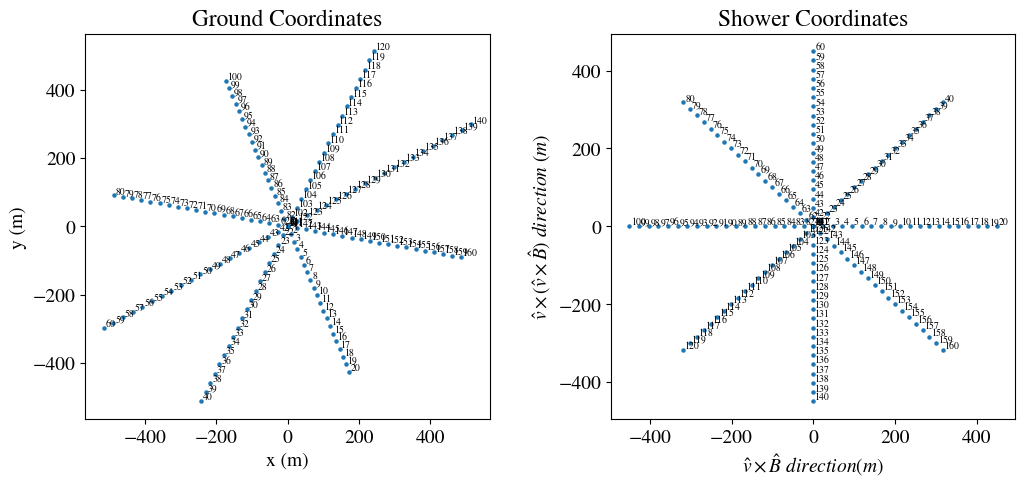

In [2]:
rmant = [label.replace("ant_", "") for label in antlabels]
vxB, vxvxB = (np.empty(160) for _ in range(2))
offset = 5
s = 5

### ground coordinate ###
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(wspace=0.3)
plot = axes[0].scatter(antx, anty, s = s)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].set_title("Ground Coordinates")

### shower coordinate ###
for i in range(len(antx)):
    g2s = GroundtoShowerCoordinates(antx[i], anty[i], [theta, phi], [Bx, By, Bz])
    new_x = g2s.vxB()
    new_y = g2s.vxvxB()
    vxB[i] = new_x
    vxvxB[i] = new_y
plot = axes[1].scatter(vxB, vxvxB, s = s)
axes[1].set_xlabel(rf"$\hat{{v}}\times\hat{{B}} \ direction (m)$")
axes[1].set_ylabel(rf"$\hat{{v}} \times (\hat{{v}}\times\hat{{B}}) \ direction \ (m)$")
axes[1].set_title("Shower Coordinates")

for i in range(len(antx)):
    axes[1].text(vxB[i] + offset, vxvxB[i] + offset, f'{rmant[i]}', fontsize=7)
    axes[0].text(antx[i] + offset, anty[i] + offset, f'{rmant[i]}', fontsize=7)

# longitudinal profile 

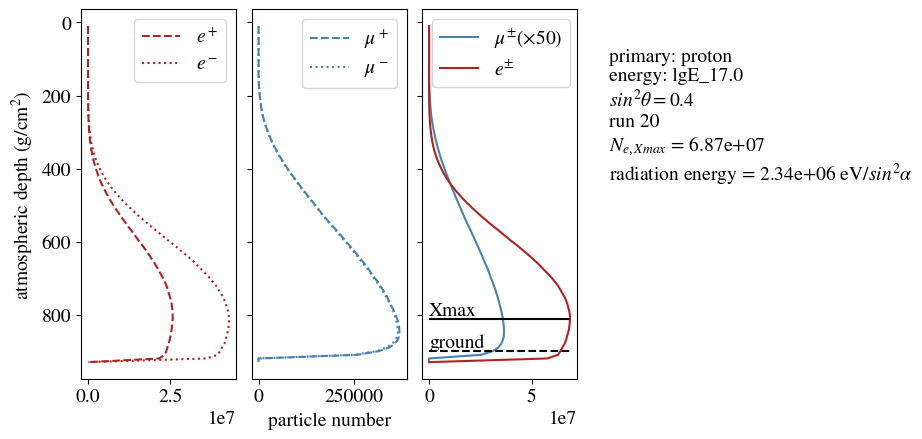

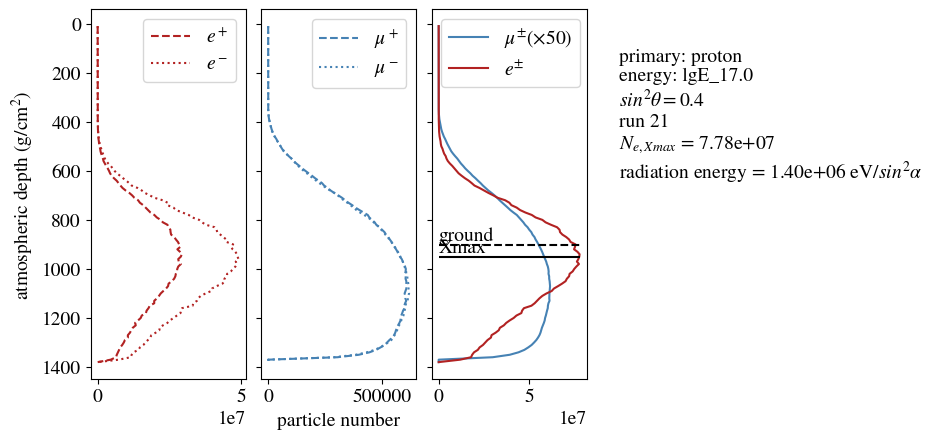

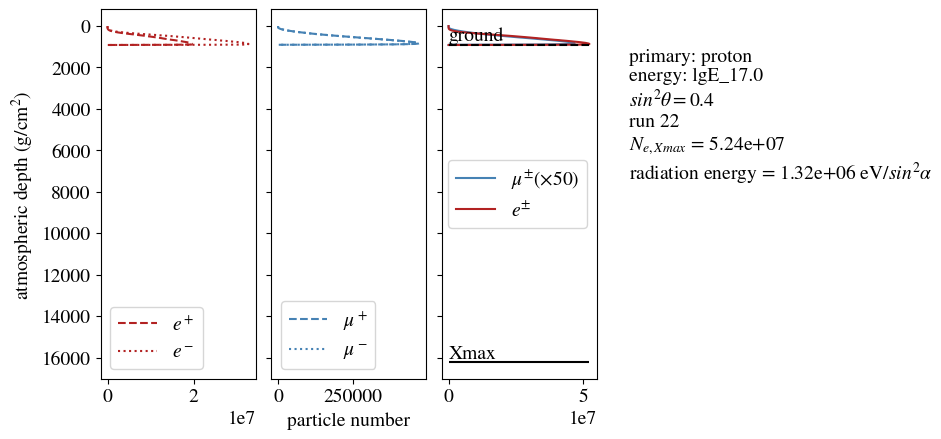

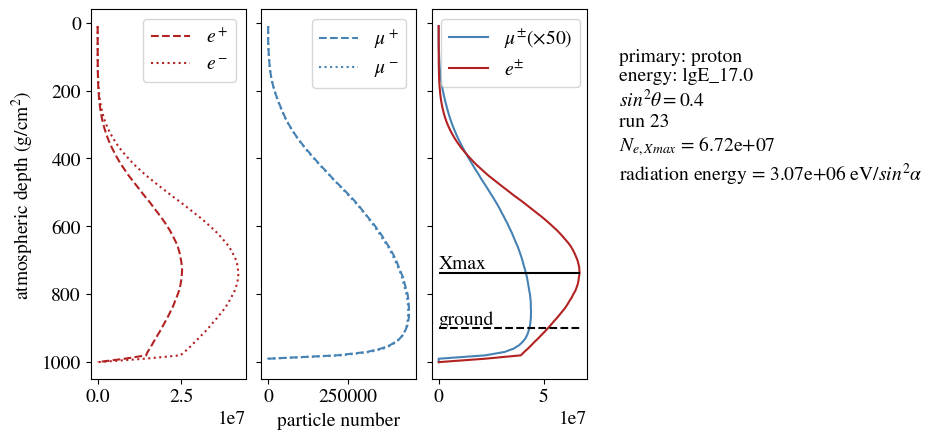

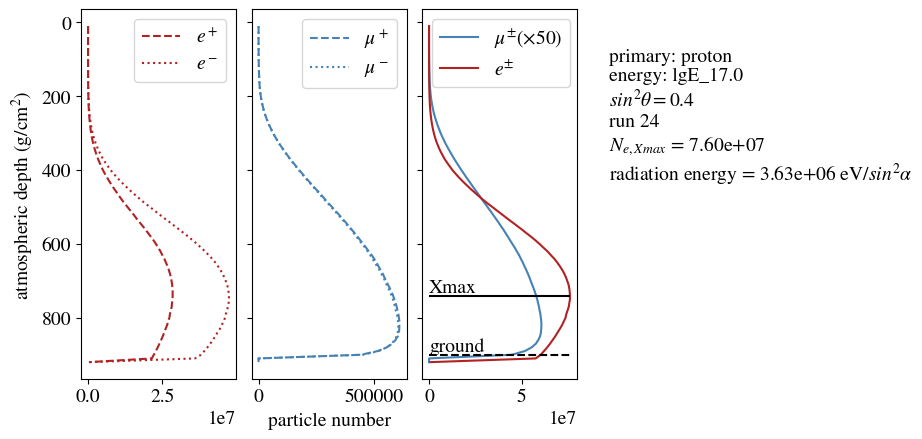

In [3]:
sin2theta = '0.4'
energy = 'lgE_17.0'
for runnum in range(20,25):
    flong = fp_long(primary, energy, sin2theta, runnum)

    # load files

    numeric_lines = []

    with open(flong) as f:
        # skip first 2 rows
        for _ in range(2):
            next(f)

        for line in f:
            try:
                # try converting all columns to float
                [float(x) for x in line.split()]
                numeric_lines.append(line)
            except ValueError:
                break  # stop at first non-numeric row

    data = np.loadtxt(StringIO("".join(numeric_lines)))
    atmdepth = data[:,0]

    # extract data
    positron = data[:,2]
    electron = data[:,3]
    tot_e = positron + electron

    muplus = data[:,4]
    muminus = data[:,5]
    tot_mu = (muplus + muminus)*50

    # Xmax data 
    fileXmax = np.loadtxt(fp_Xmax(primary, energy, sin2theta))
    Ne_Xmax = fileXmax[:,3][runnum]
    Xmax = fileXmax[:,1][runnum]

    # RadE data
    fRadE = fp_RadE_norm2(primary, energy, sin2theta)
    fileRadE = np.load(fRadE)
    RadE = fileRadE['radE(eV)'][runnum]

    # ground level
    X0 = 697.6 #g/cm^2
    thetafloat = float(sin2theta)
    costheta = np.cos(np.arcsin(np.sqrt(thetafloat)))
    Xv = X0/ costheta

    # plot
    pltlp(atmdepth, positron, electron, muplus, muminus, tot_e, tot_mu, Xmax, Ne_Xmax, RadE, runnum, Xv)

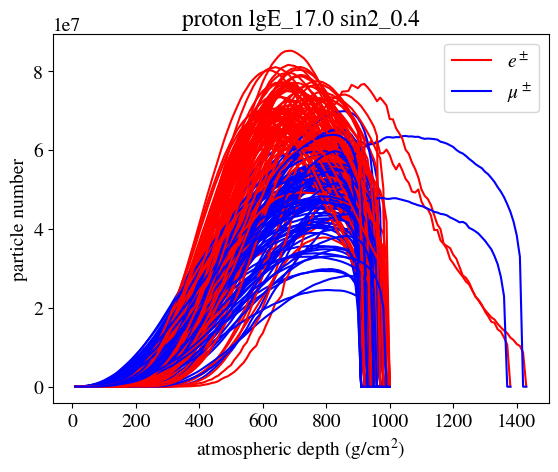

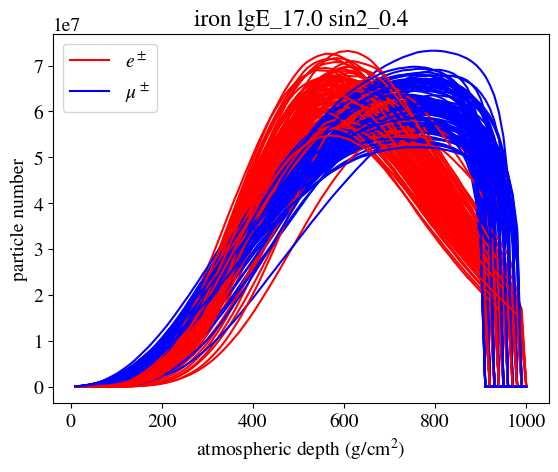

In [4]:
primary_array = ['proton', 'iron']
sin2theta = '0.4'
energy = 'lgE_17.0'

for primary in primary_array:
	for runnum in range(101,199):
		flong = fp_long(primary, energy, sin2theta, runnum)

		# load files
		numeric_lines = []

		with open(flong) as f:
			# skip first 2 rows
			for _ in range(2):
				next(f)

			for line in f:
				try:
					# try converting all columns to float
					[float(x) for x in line.split()]
					numeric_lines.append(line)
				except ValueError:
					break  # stop at first non-numeric row

		data = np.loadtxt(StringIO("".join(numeric_lines)))
		atmdepth = data[:,0]

		# extract data
		positron = data[:,2]
		electron = data[:,3]
		tot_e = positron + electron

		muplus = data[:,4]
		muminus = data[:,5]
		tot_mu = (muplus + muminus)*50

		# Xmax data 
		fileXmax = np.loadtxt(fp_Xmax(primary, energy, sin2theta))
		Ne_Xmax = fileXmax[:,3][runnum]
		Xmax = fileXmax[:,1][runnum]

		# RadE data
		fRadE = fp_RadE_norm2(primary, energy, sin2theta)
		fileRadE = np.load(fRadE)
		RadE = fileRadE['radE(eV)'][runnum]

		# ground level
		X0 = 697.6 #g/cm^2
		thetafloat = float(sin2theta)
		costheta = np.cos(np.arcsin(np.sqrt(thetafloat)))
		Xv = X0/ costheta

		
		plt.plot(atmdepth, tot_e, color = 'r')
		plt.plot(atmdepth, tot_mu, color = 'b')
	
	plt.title(rf'{primary} {energy} sin2_{0.4}')
	plt.legend([rf'$e^\pm$', rf'$\mu^\pm$'])
	plt.xlabel(rf'atmospheric depth ($\mathrm{{g/cm^2}}$)')
	plt.ylabel('particle number')
	# plt.xlim(0,1000)
	plt.show()
    


# particle distributions

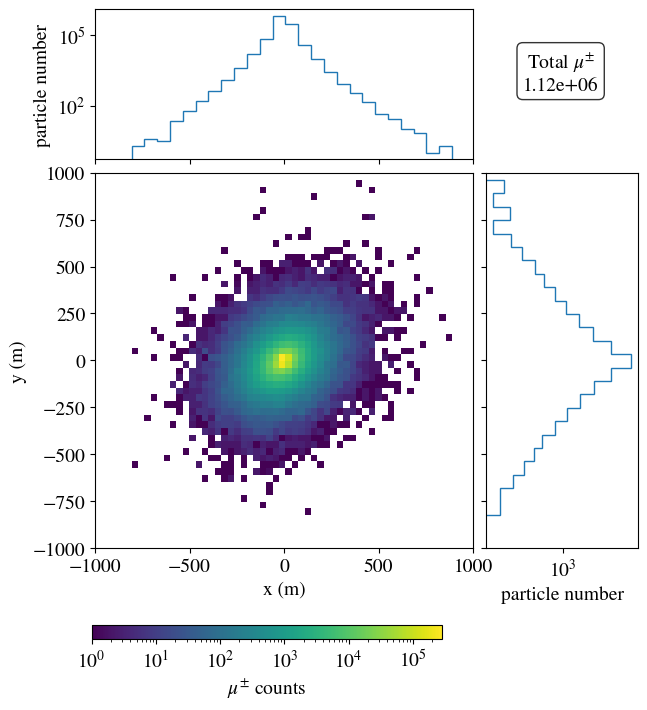

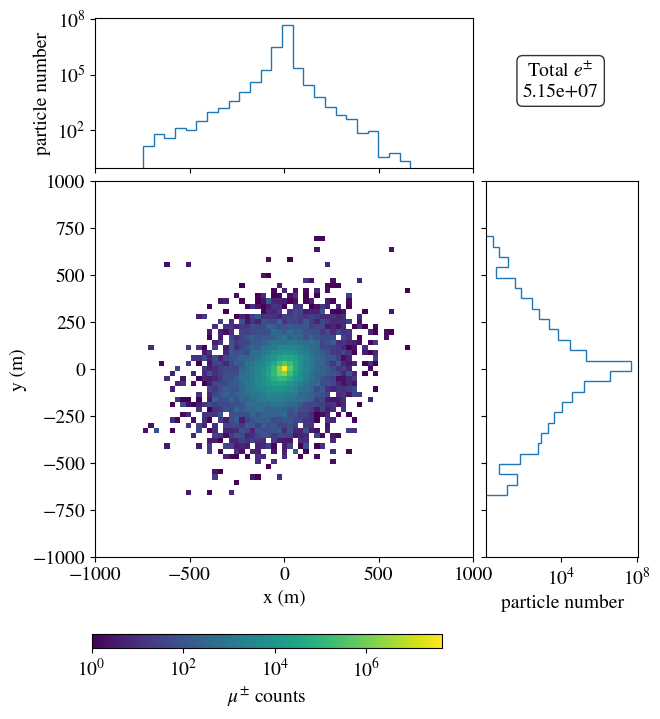

In [4]:
pltNpar(mux, muy, w_mu, 'muon')
pltNpar(ex, ey, w_e, 'electron')

# Nmu, Ne correlation

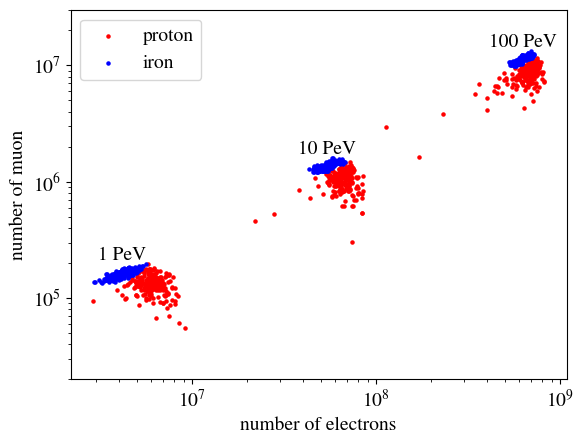

In [5]:
energies = [16.0, 17.0, 18.0] ## Energy logE 
energylabel = ["1 PeV", "10 PeV", "100 PeV"]
sin2theta = 0.0
for i in range (len(energies)):
    labels = energylabel[i]
    pltmuecorr(energies[i], sin2theta, labels)

# Energy radiation with bandpass filter

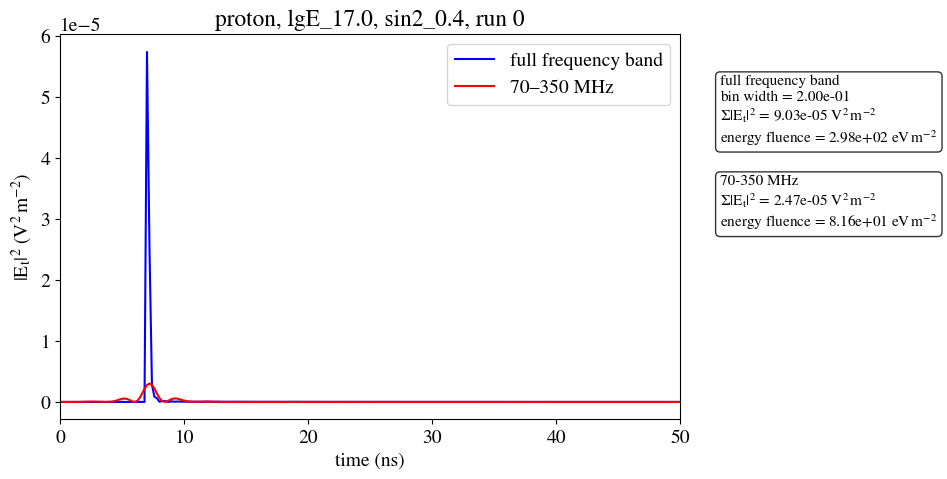

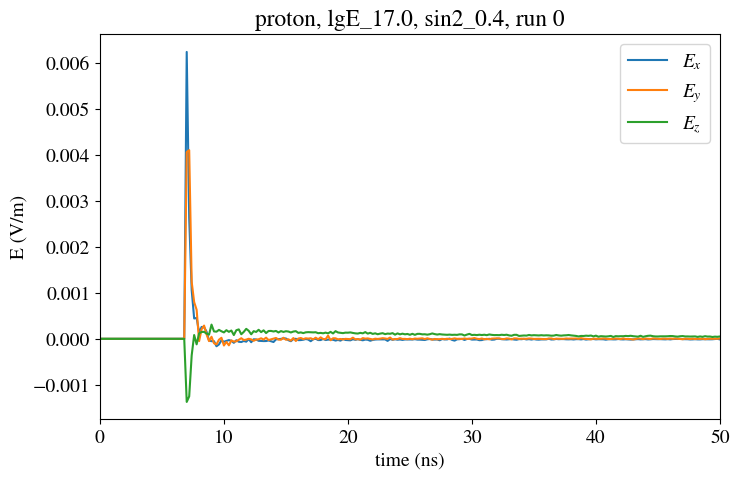

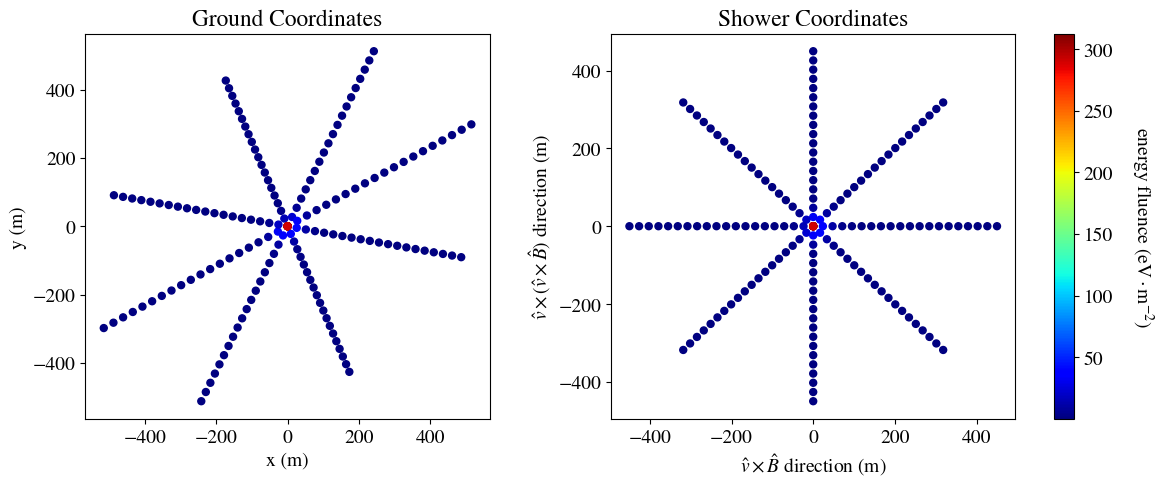

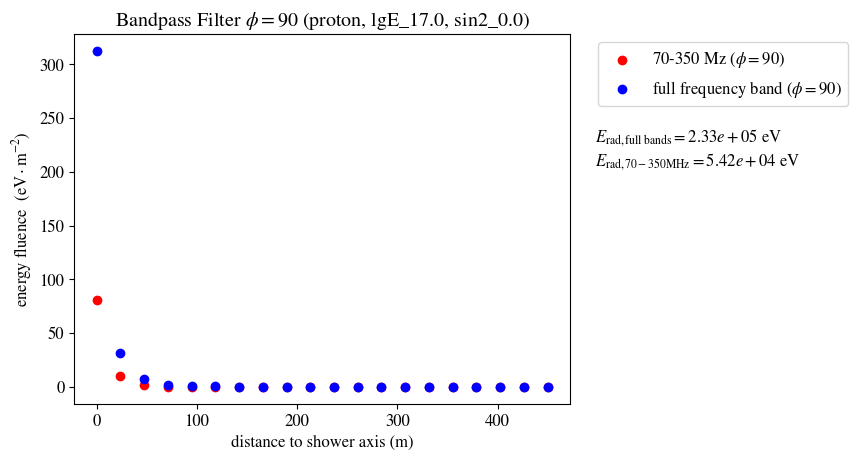

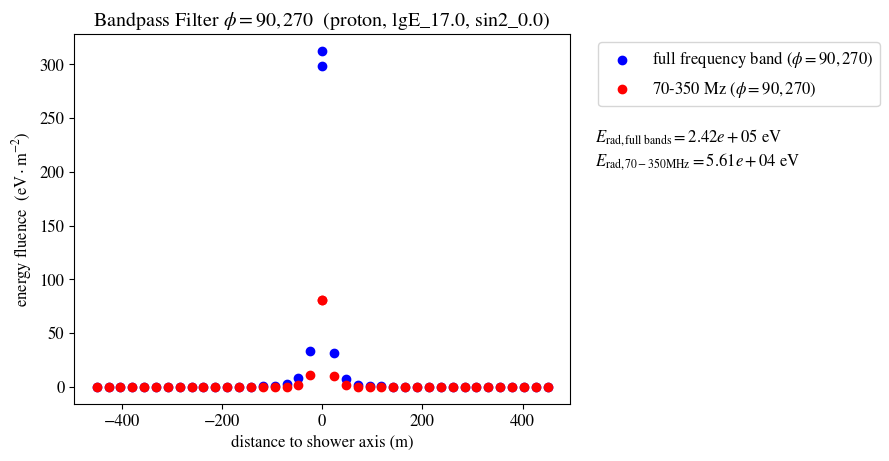

(40, 40)

In [6]:
Nant = 160 #number of total antennas
# create empty arrays of energy fluence, filtered energy fluence, vxB, and vxvxB
ef, eff, vxB, vxvxB = (np.empty(Nant) for _ in range(4))


# 160 antenna (Nant = 160) loop
for i, ant_no in enumerate(range (1,Nant+1)):
    
    radio_dat = np.loadtxt(fp_radio(primary, energy, sin2theta, runnum, ant_no))

    # extract data
    time = radio_dat[:,0]*1e9
    E_SI = 29979 # electric field converter from cgs unit to SI unit 1 statV/cm≈29,979 V/m
    Ex, Ey, Ez = radio_dat[:,1]*E_SI, radio_dat[:,2]*E_SI, radio_dat[:,3]*E_SI # north, west, vertical electric field in V/m

    #filter electric field using signal.butter
    b, a = signal.butter(5, [70e6, 350e6] , 'bp', fs=5e9)
    Ex_f, Ey_f, Ez_f = (signal.filtfilt(b, a, i) for i in (Ex, Ey, Ez))

    # |E|^2 raw and filtered
    Emag2, Emag2_f = magE2(Ex, Ey, Ez), magE2(Ex_f, Ey_f, Ez_f) 

    # sum(|E|^2)
    E_sum, E_sum_f = sum(Emag2), sum(Emag2_f)
     
    # energy fluence 
    ef[i], eff[i] = energyfluence(E_sum), energyfluence(E_sum_f)

    # plot |E|^2 histogram for antenna number 1 
    if ant_no == 1:
        pltEmag2(ant_no, time, time, Emag2, Emag2_f, E_sum, E_sum_f, 'bp')
        pltE(ant_no, time, Ex,Ey, Ez)
        
# plot energy fluence map choose weather colors = ef or colors = eff
pltefmap(finp, Nant, vxB, vxvxB, antx, anty, ef)
# plot radius vs energy fluence
xmin, xmax = -500, 500
pltef(vxB, vxvxB, ef, eff, 'bp', xmin, xmax, 'linear', primary, energy, sin2theta)

# Energy radiation with FFT

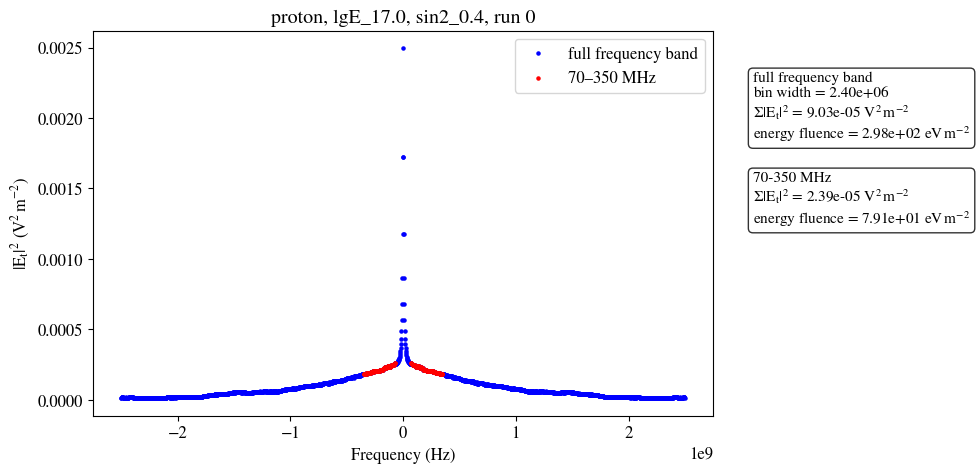

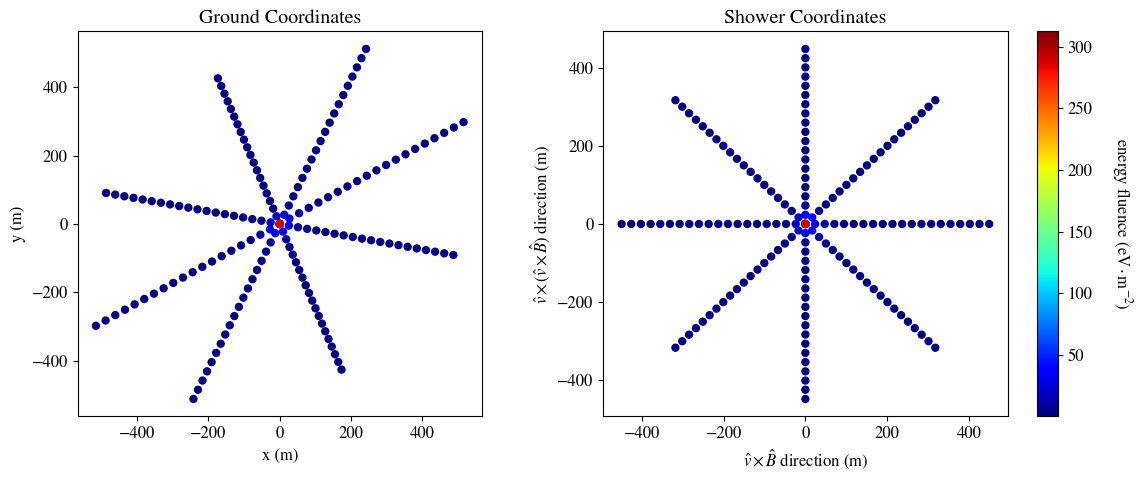

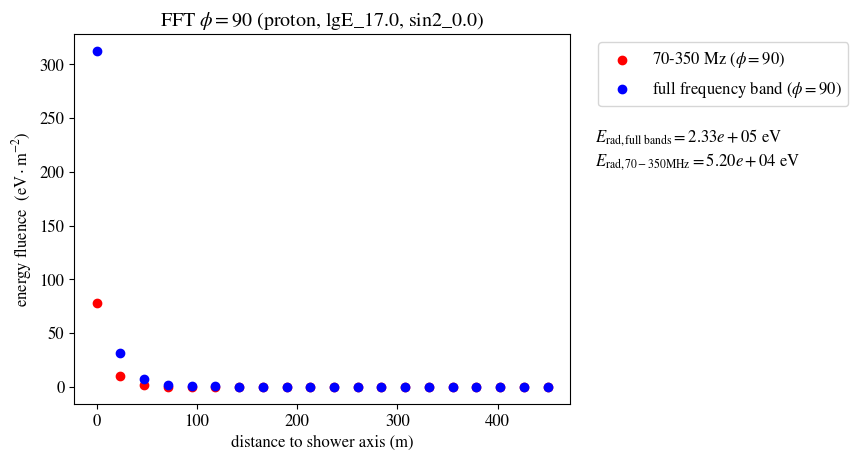

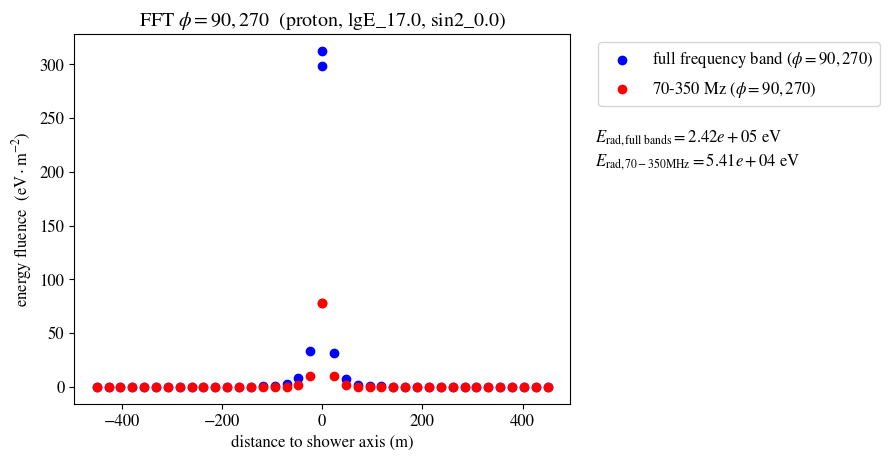

(40, 40)

In [7]:
Nant = 160 #number of total antennas
# create empty arrays of energy fluence, filtered energy fluence, vxB, and vxvxB
ef, eff, vxB, vxvxB = (np.empty(Nant) for _ in range(4))

fmin,fmax = 70e6, 350e6 # frequency range 70-350 MHz

# 160 antenna (Nant = 160) loop
for i, ant_no in enumerate(range (1,Nant+1)):
    
    radio_dat = np.loadtxt(fp_radio(primary, energy, sin2theta, runnum, ant_no))

    # extract data
    time = radio_dat[:,0]
    E_SI = 29979 # electric field converter from cgs unit to SI unit 1 statV/cm≈29,979 V/m
    Ex, Ey, Ez = radio_dat[:,1]*E_SI, radio_dat[:,2]*E_SI, radio_dat[:,3]*E_SI # north, west, vertical electric field in V/m
    Er = np.sqrt(Ex**2 + Ey**2 + Ez**2) 

    # FFT
    dt = time[1] - time[0]
    N  = len(time)
    Efft = fft.fft(Er) # real valued signal, use rfft
    freq = (np.fft.fftfreq(N, dt))

    Efft2 = abs(Efft)**2
    E_sum = fftsum(N, Efft2)

    # restrict energy range
    mask = (abs(freq) >= fmin) & (abs(freq) <= fmax)
    Efft2_mask = abs(Efft[mask])**2
    freq_f = freq[mask]
    E_sum_f = fftsum(N, Efft2_mask)

    # energy fluence 
    ef[i], eff[i] = energyfluence(E_sum), energyfluence(E_sum_f)

    # plot |E|^2 histogram for antenna number 1 
    if ant_no == 1:
        pltEmag2(ant_no, freq, freq_f, Efft2, Efft2_mask, E_sum, E_sum_f, 'fft')

# plot energy fluence map choose weather colors = ef or colors = eff
pltefmap(finp, Nant, vxB, vxvxB, antx, anty, ef)

# plot radius vs energy fluence
# pltef(vxB, vxvxB, ef, eff, 'fft')
xmin, xmax = -500, 500
# pltef(vxB, vxvxB, ef, eff, 'fft', xmin, xmax, 'log')
pltef(vxB, vxvxB, ef, eff, 'fft', xmin, xmax, 'linear', primary, energy, sin2theta)

# Ne vs. Radiation Energy

## NeGround vs Radiation Energy

posx and posy should be finite values
posx and posy should be finite values


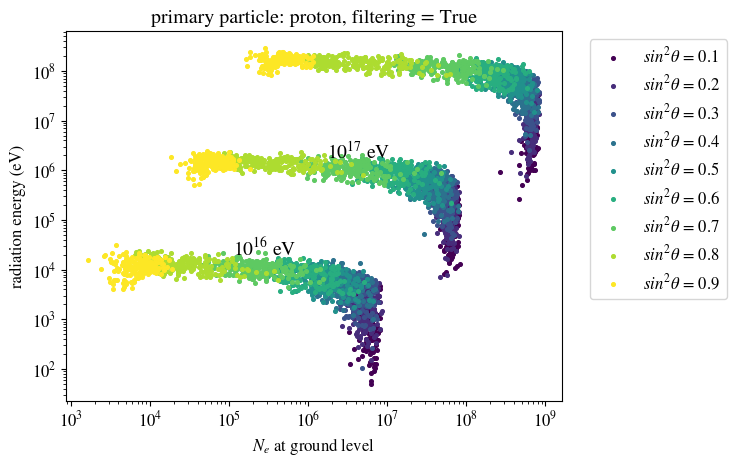

In [8]:
sin2thetas = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7",  "0.8", "0.9"]
primary = ["proton"]
energy = ["lgE_16.0", "lgE_17.0","lgE_18.0"]
labels = [rf'$10^{{16}}$ eV', rf'$10^{{17}}$ eV', rf'$10^{{18}}$ eV']
filtering = True
norm = False
pltRadE_NeGround(sin2thetas, primary, energy, labels, norm = norm, filtering = filtering)

## NeXmax vs Radiation Energy

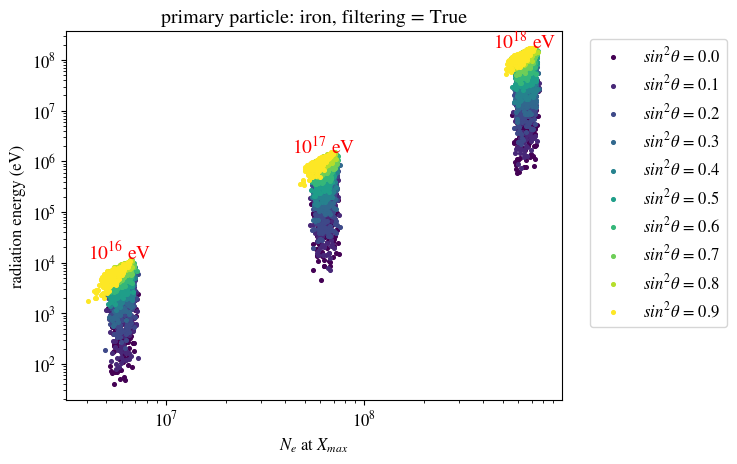

In [9]:
sin2thetas = ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7",  "0.8", "0.9"]
primary = ["iron"]
energy = ["lgE_16.0", "lgE_17.0", "lgE_18.0"]
labels = [rf'$10^{{16}}$ eV',rf'$10^{{17}}$ eV', rf'$10^{{18}}$ eV']
norm = False
filtering = True
pltRadE_NeXmax(sin2thetas, primary, energy, labels, norm = norm, filtering = filtering)

## Ne ratio vs Xmax

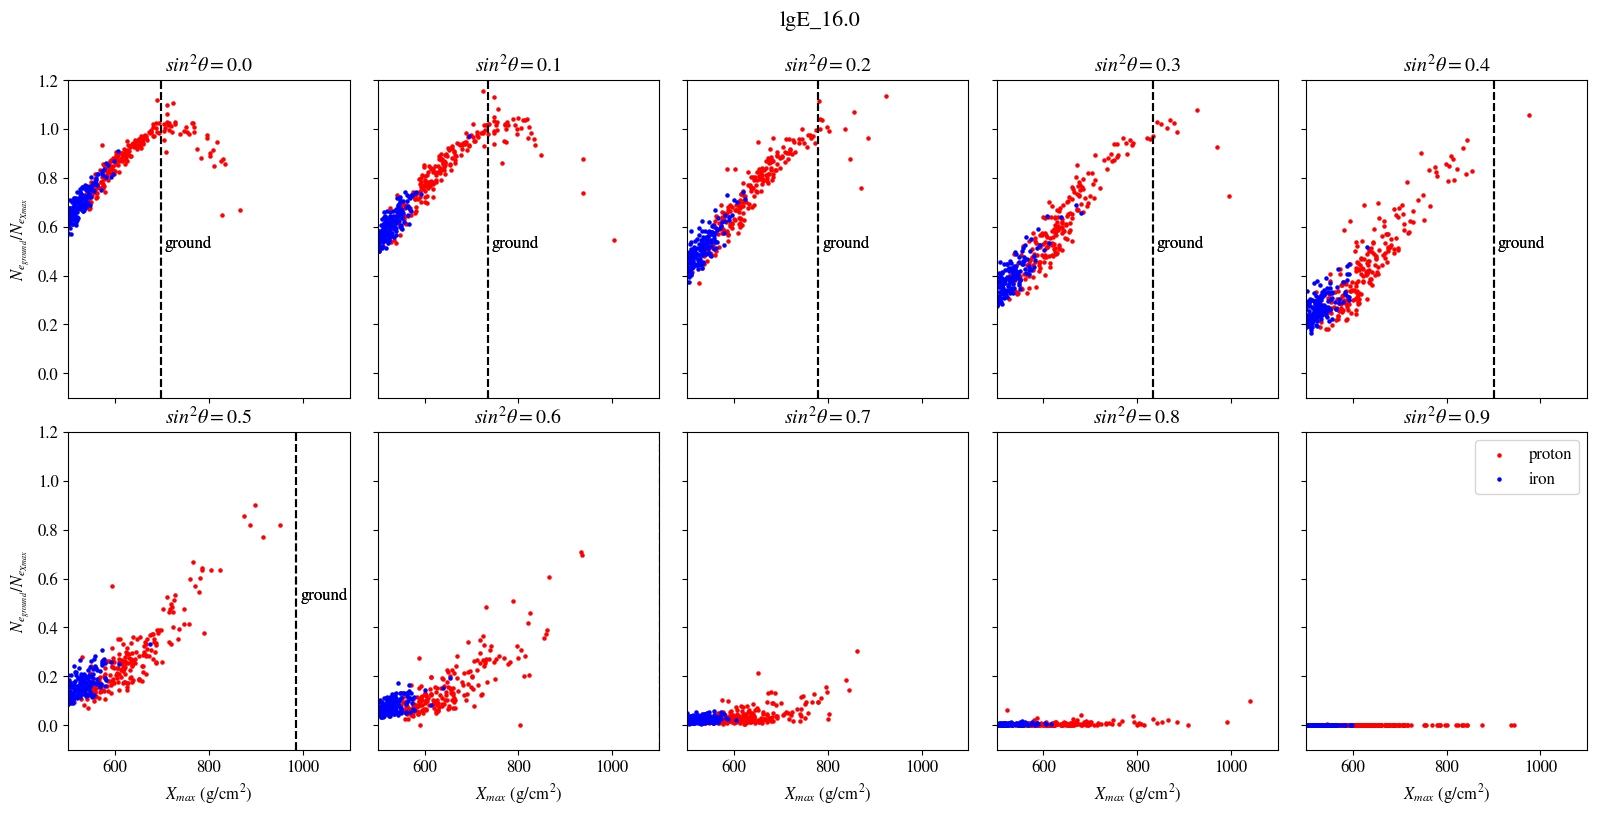

In [10]:
energy = ["lgE_16.0"]
pltNeRatio(energy,style = 'horiz') # style = 'horiz' or style = 'verti'

## Ne,Xmax vs Xmax vs Radiation Energy

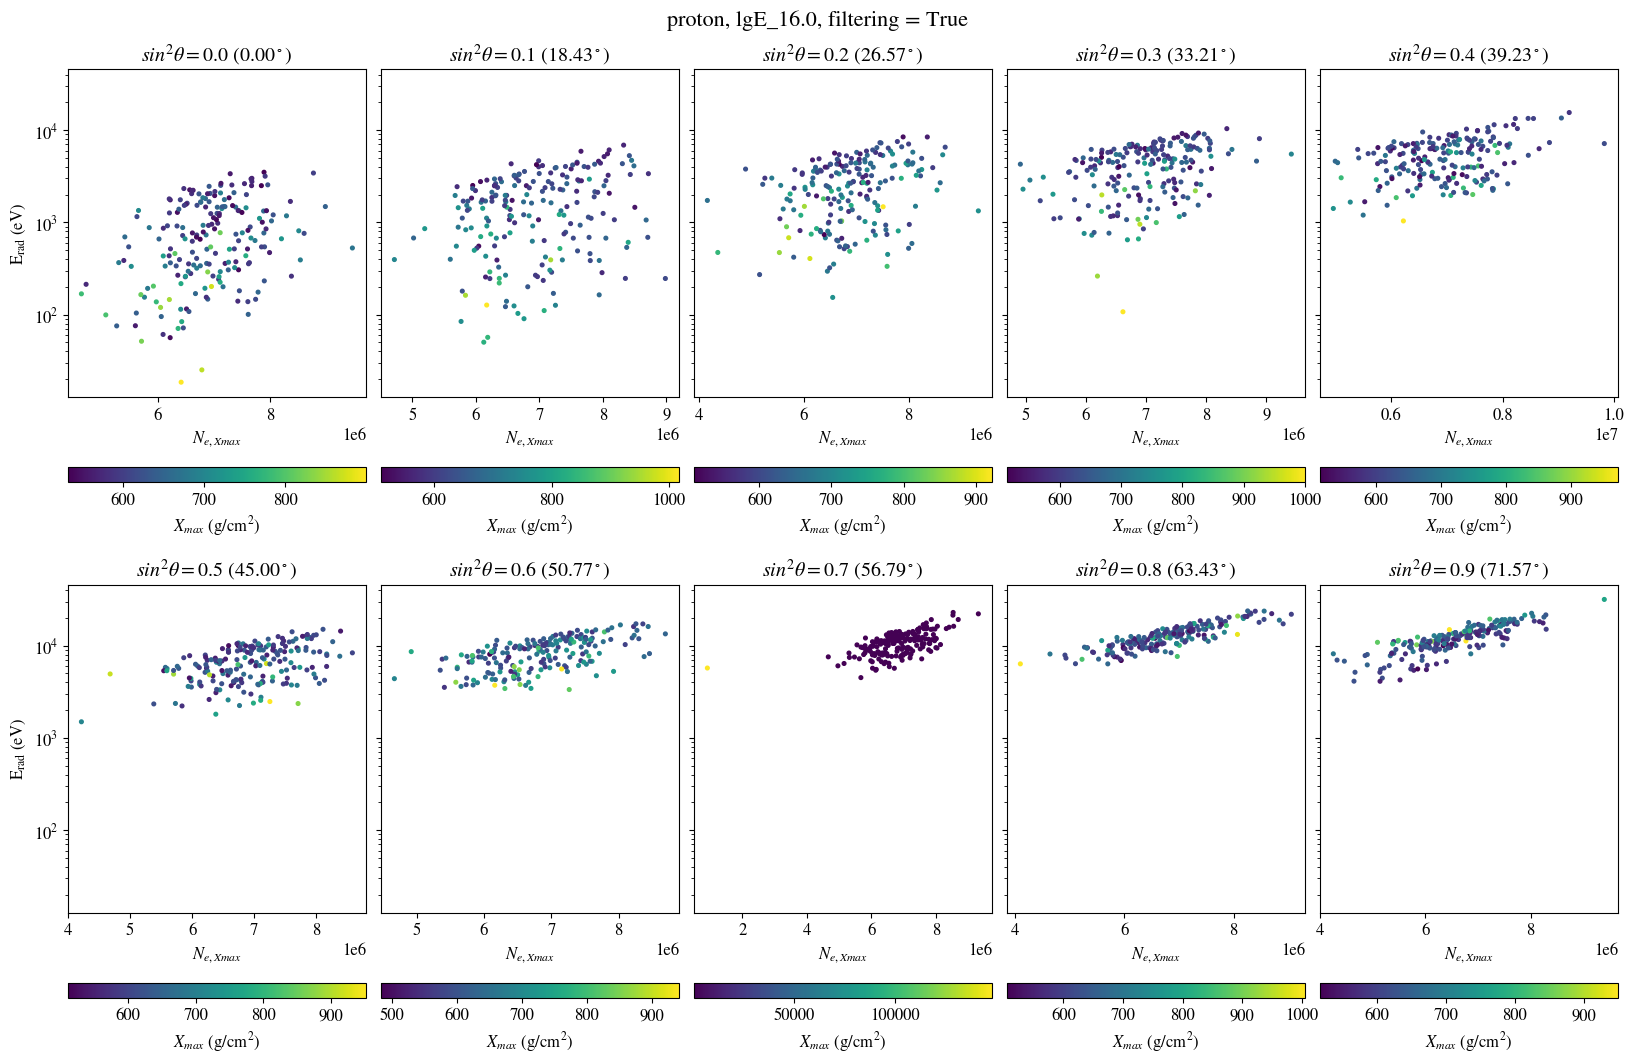

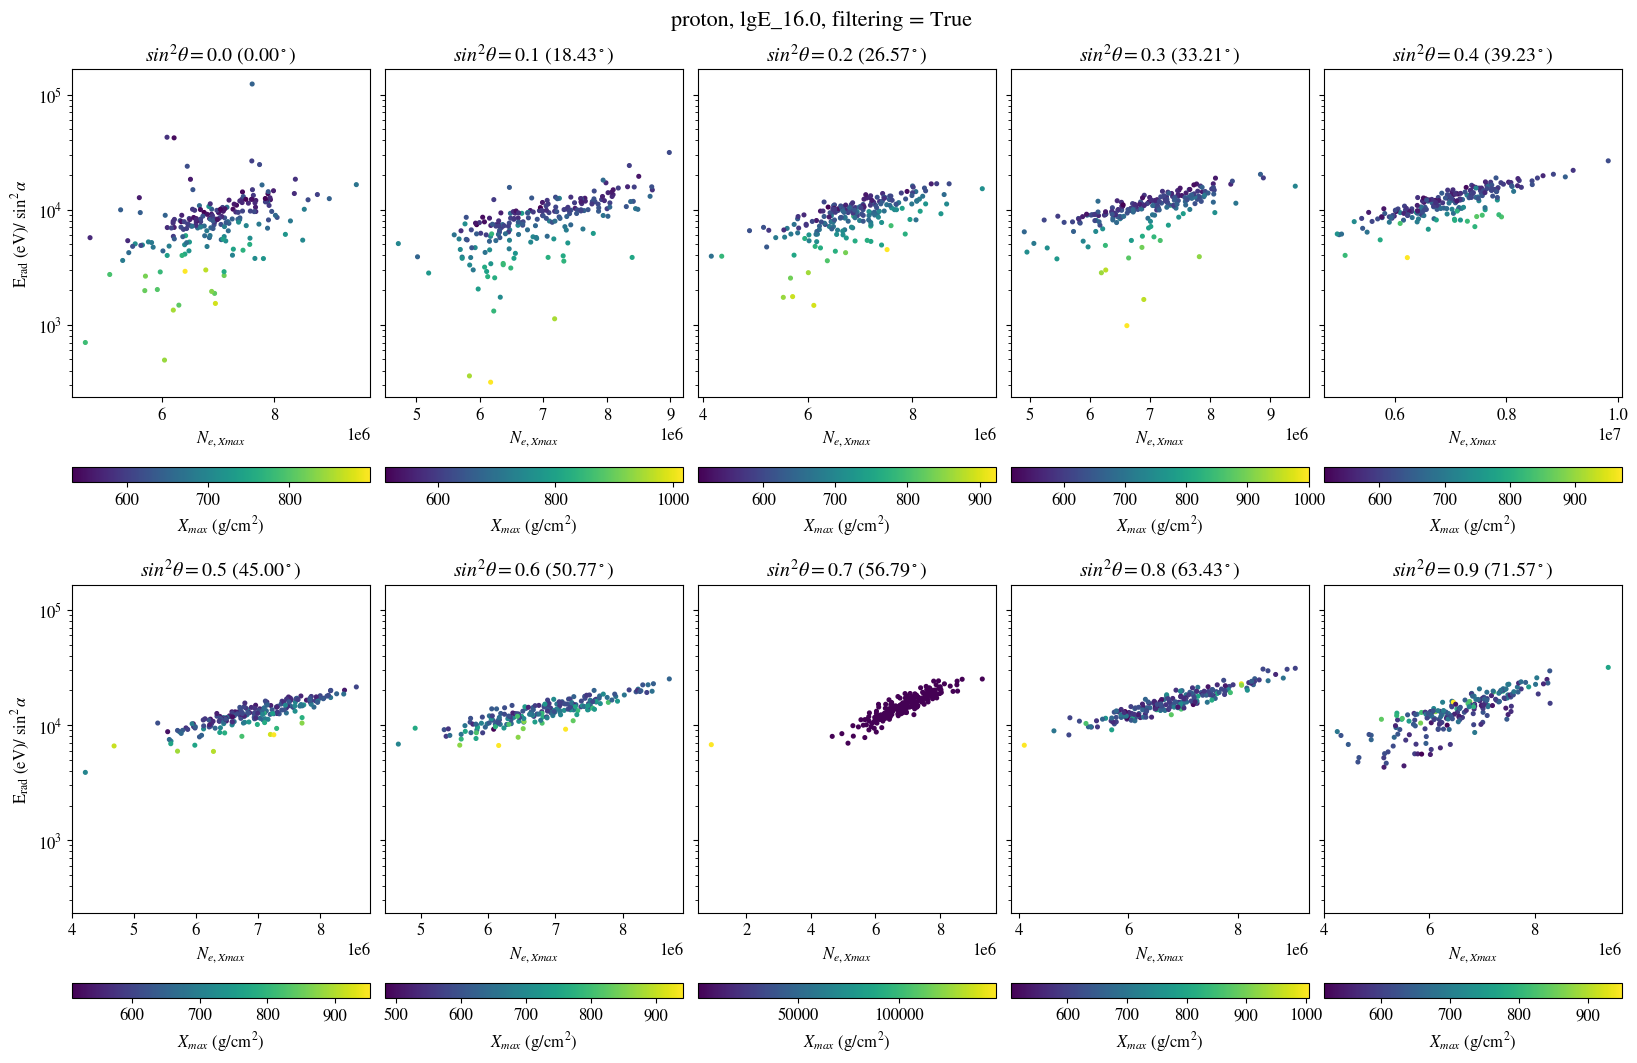

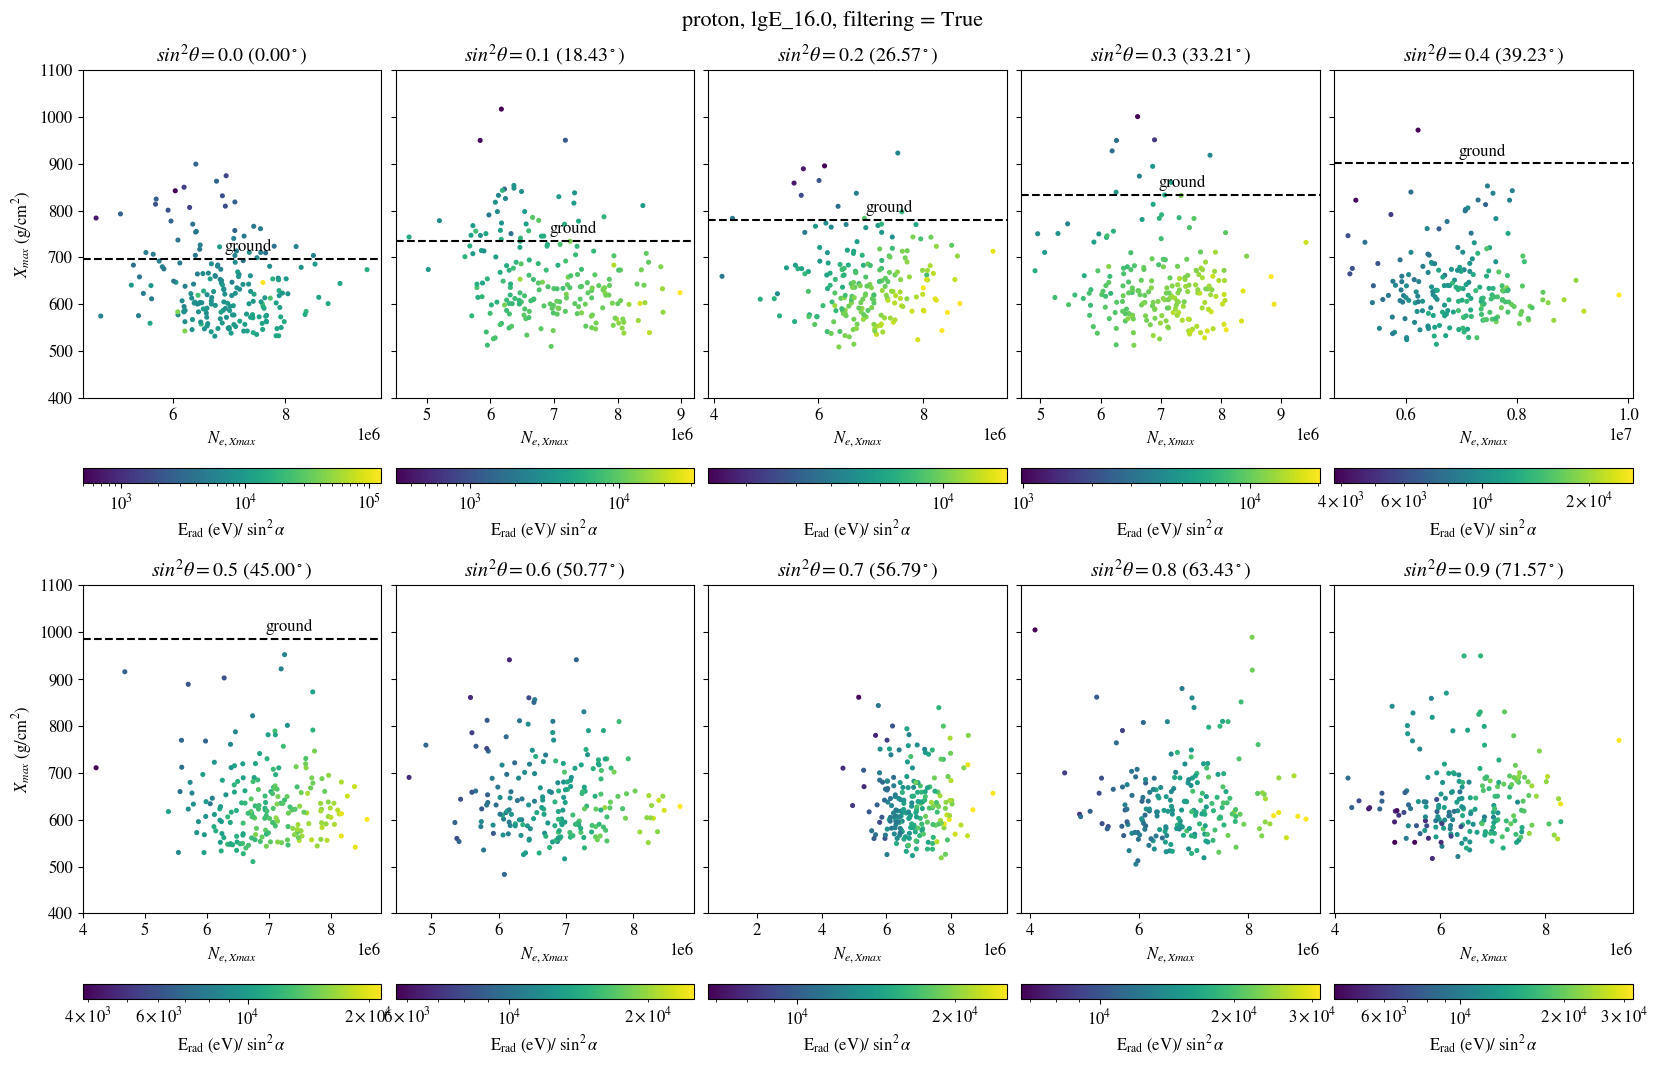

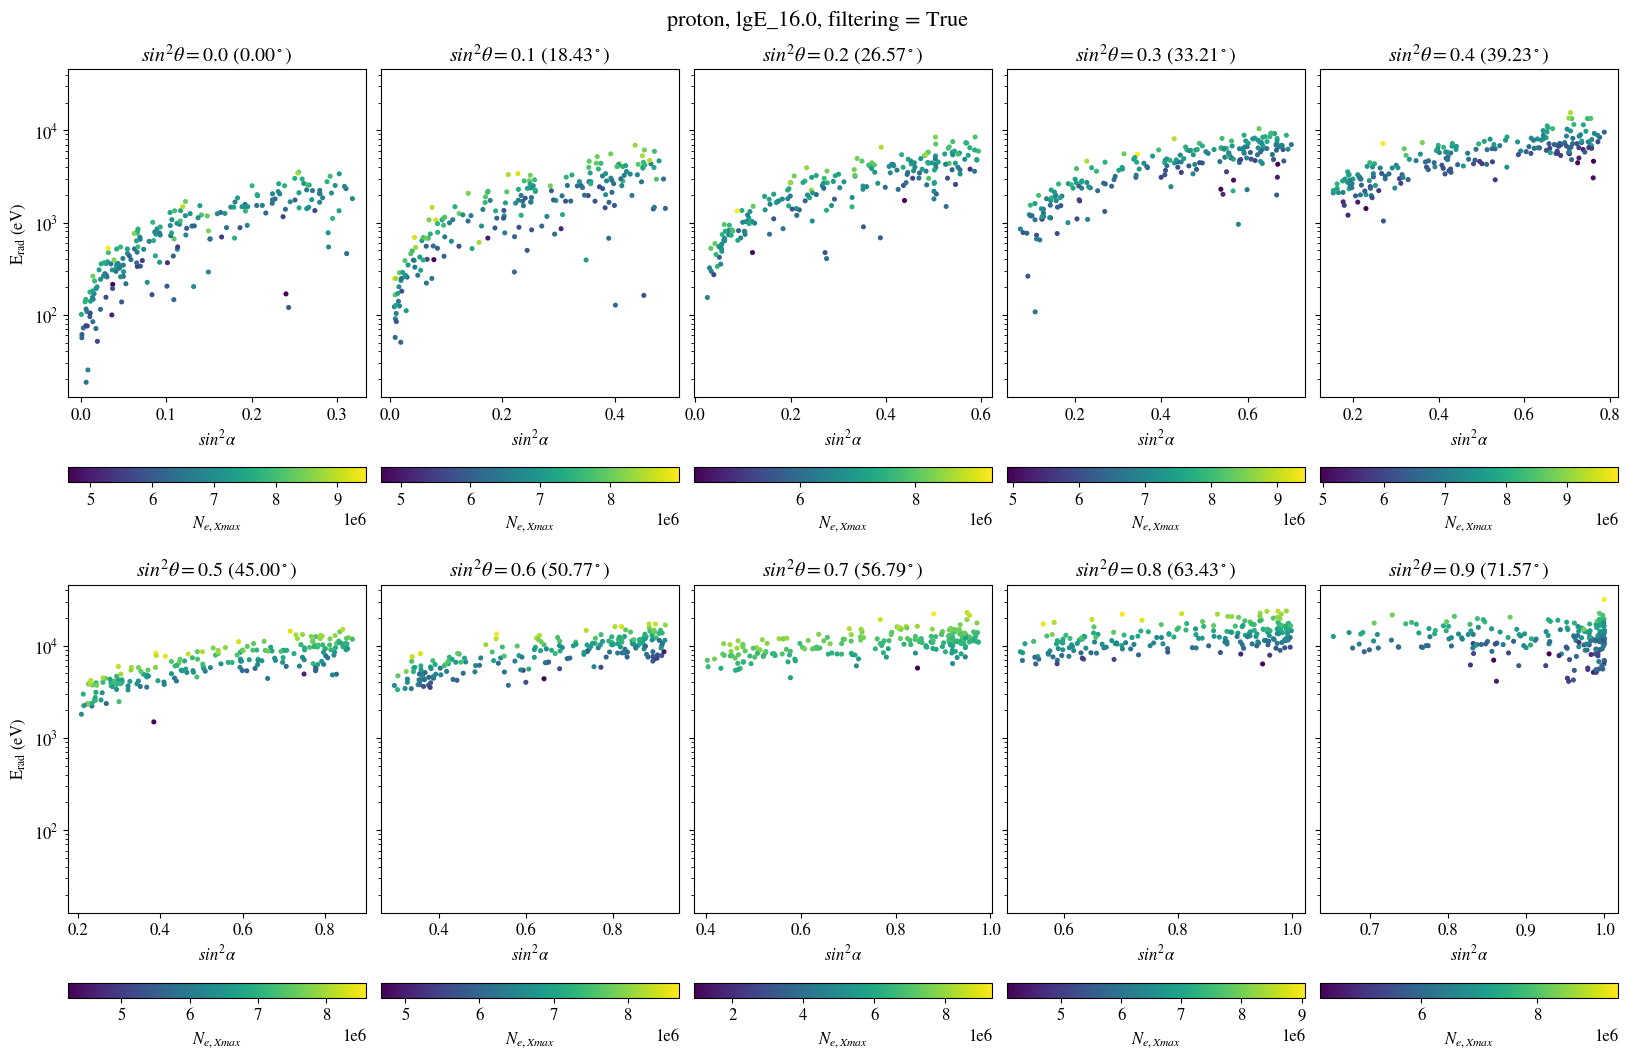

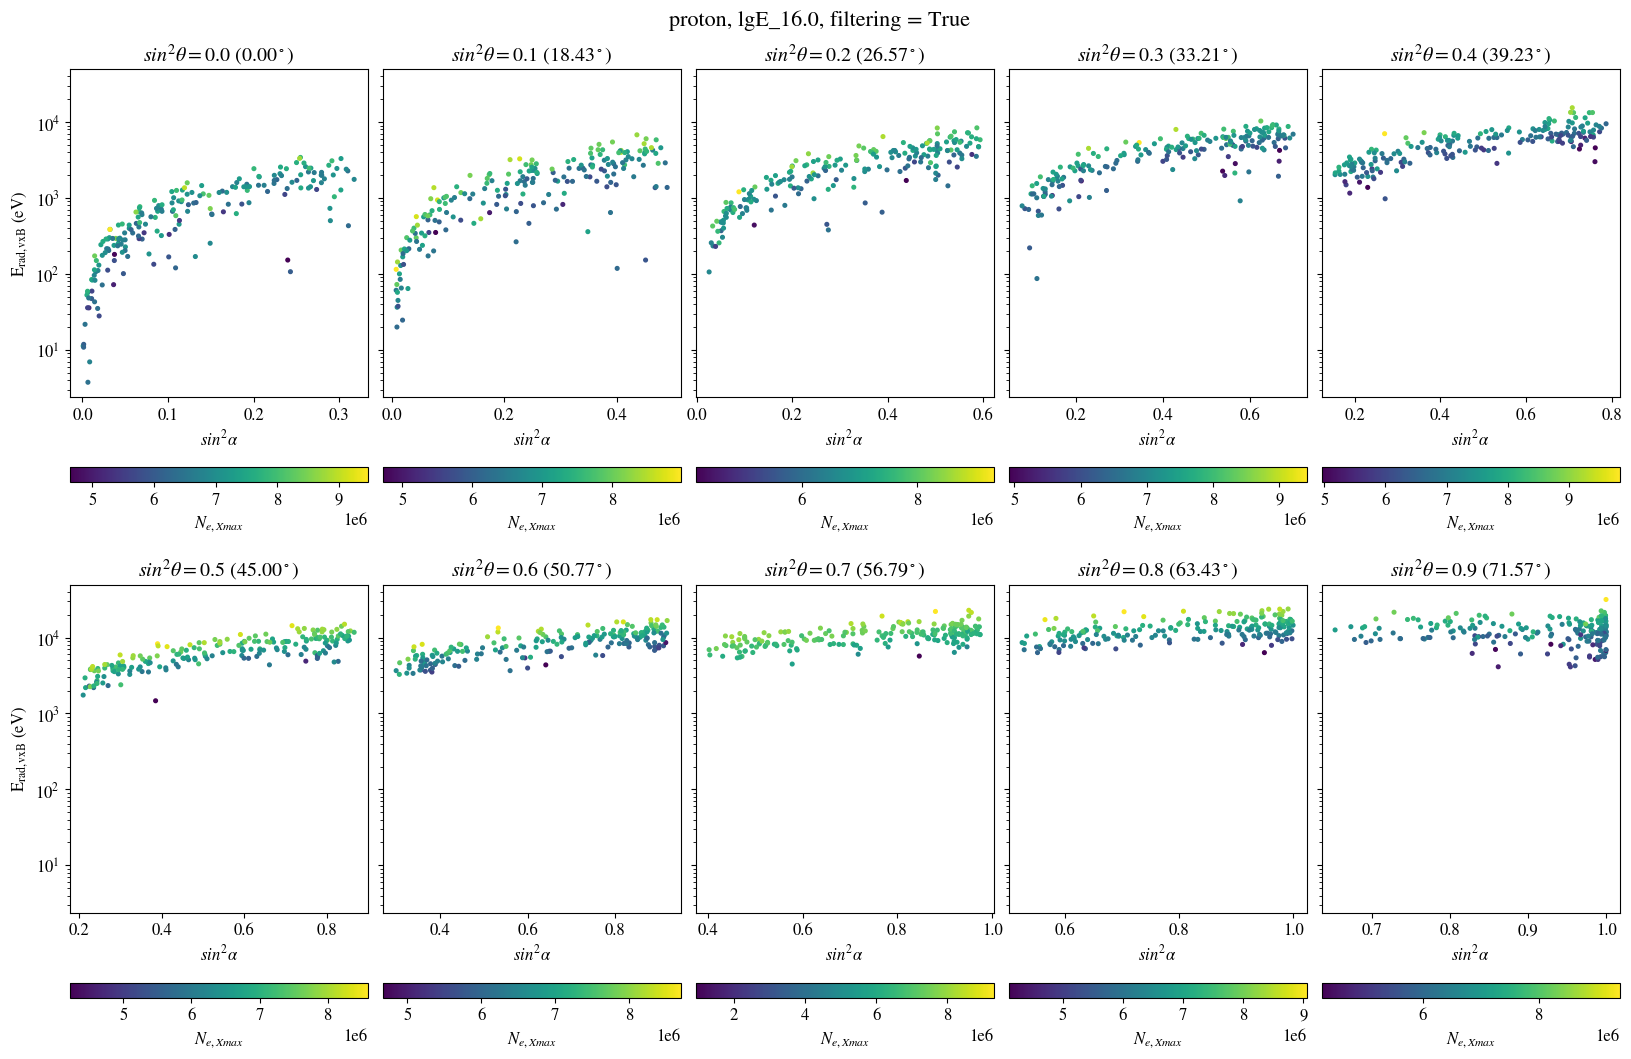

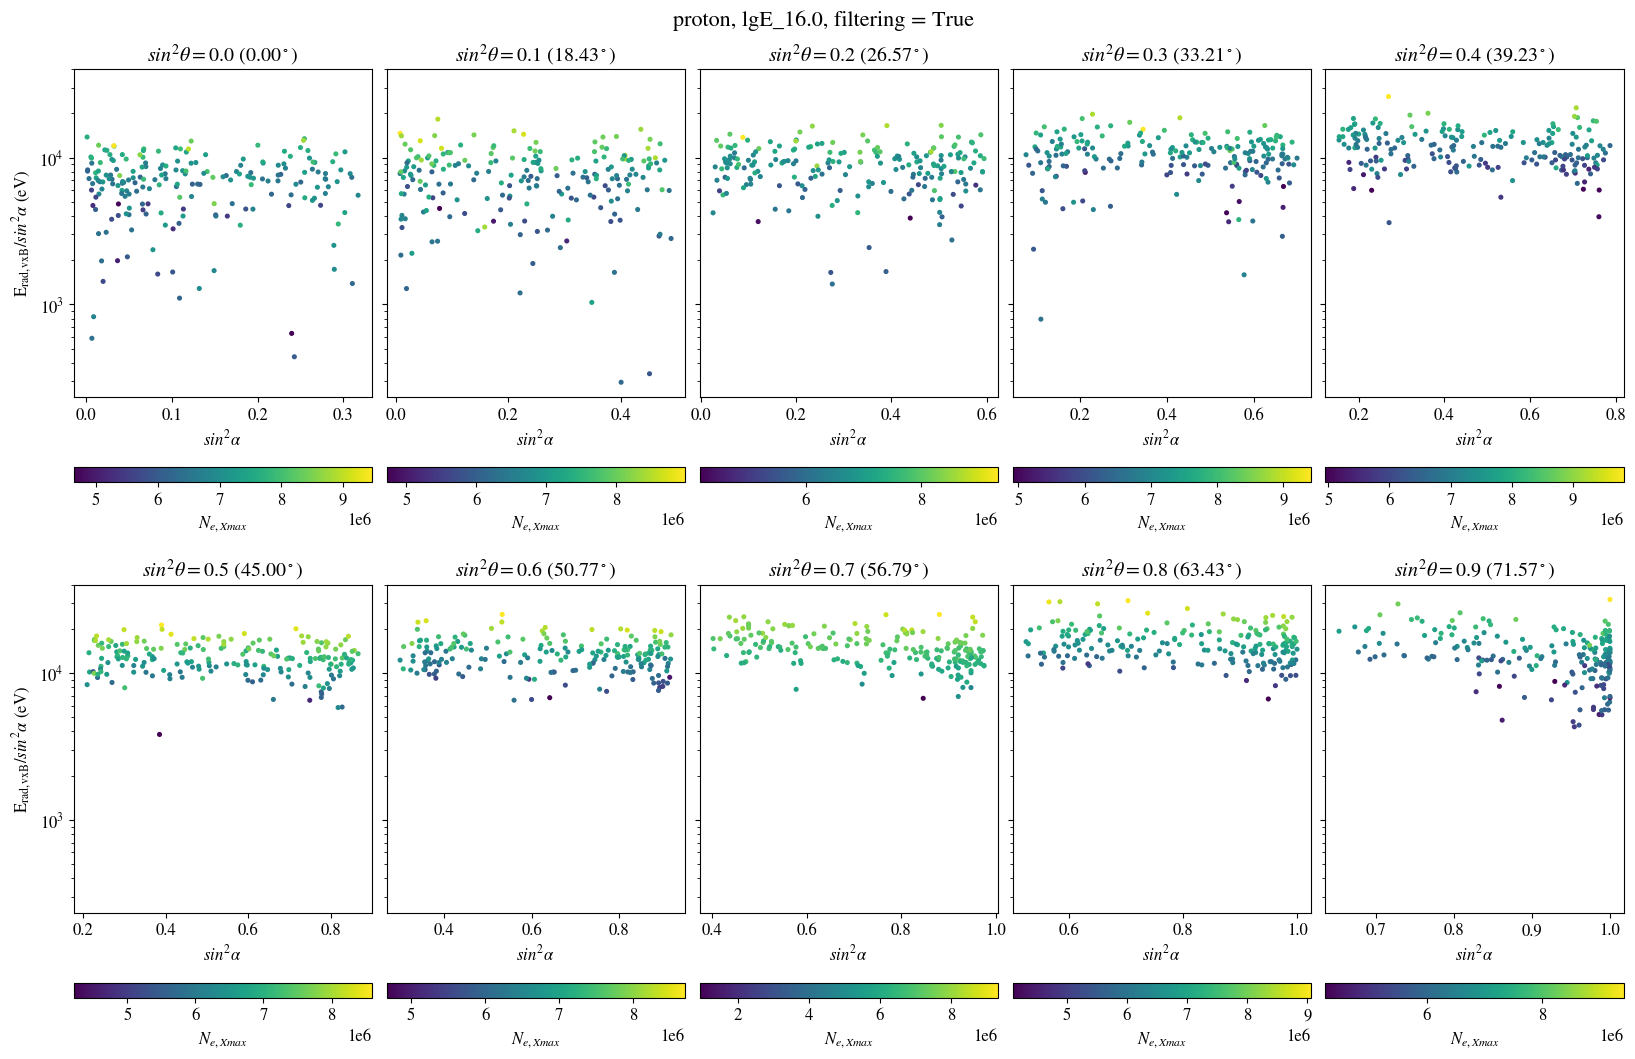

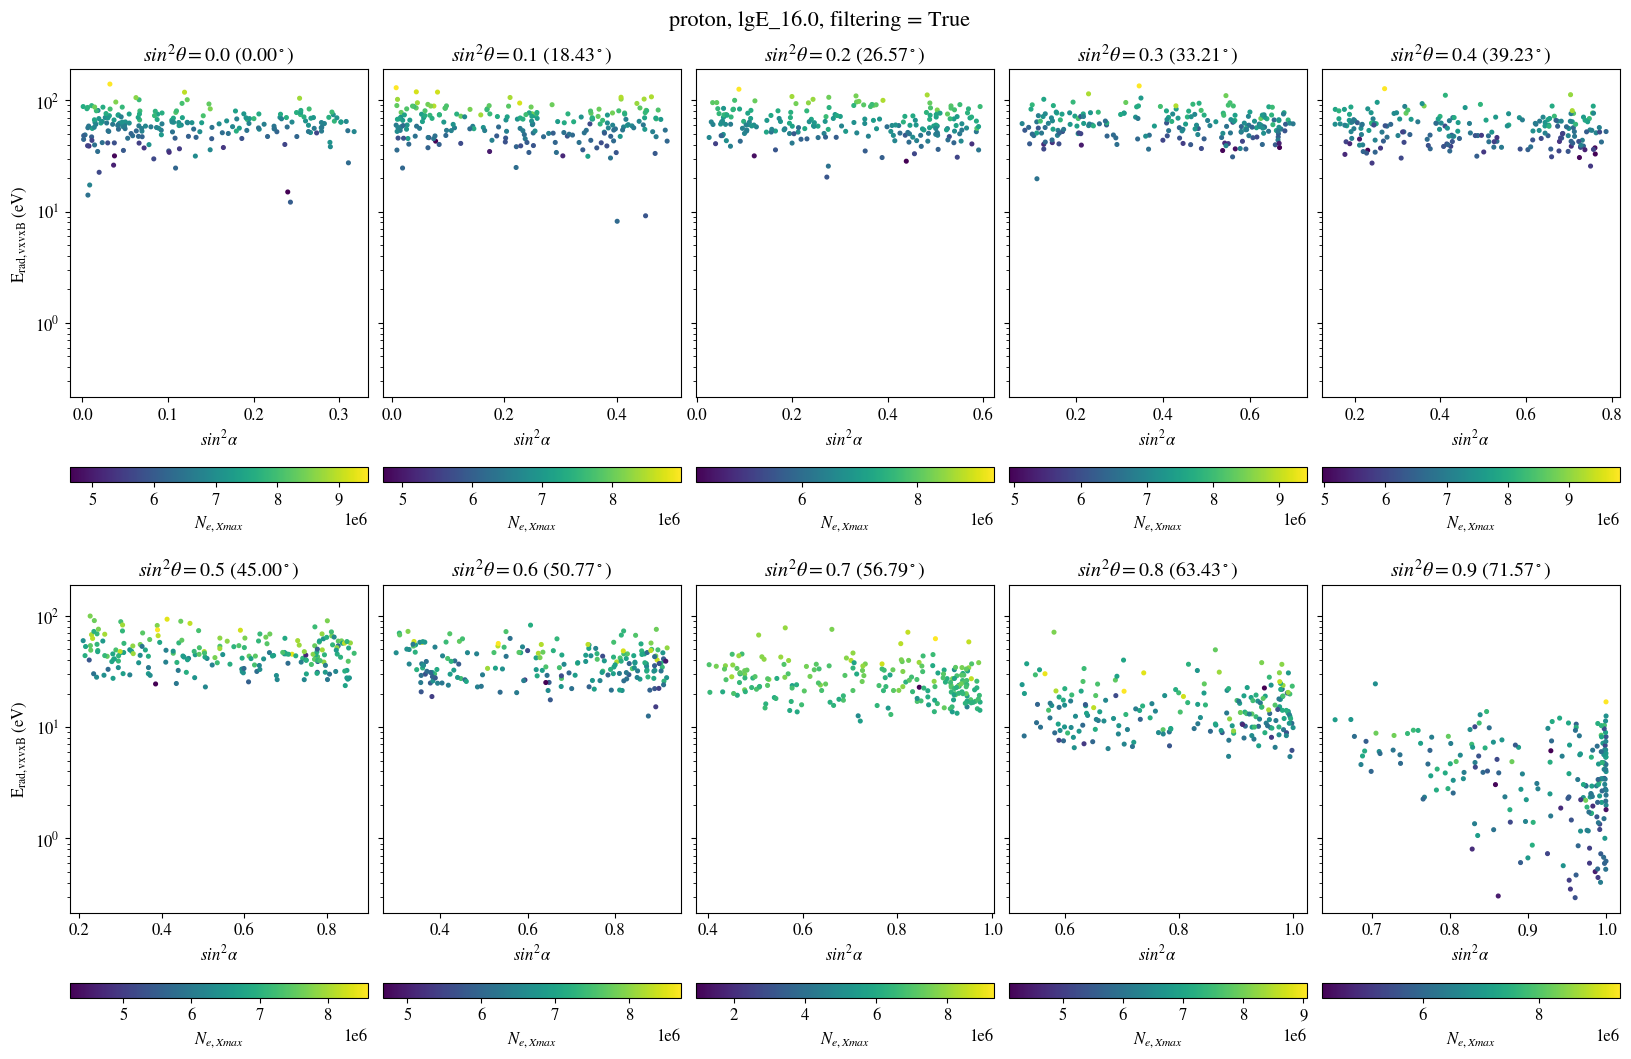

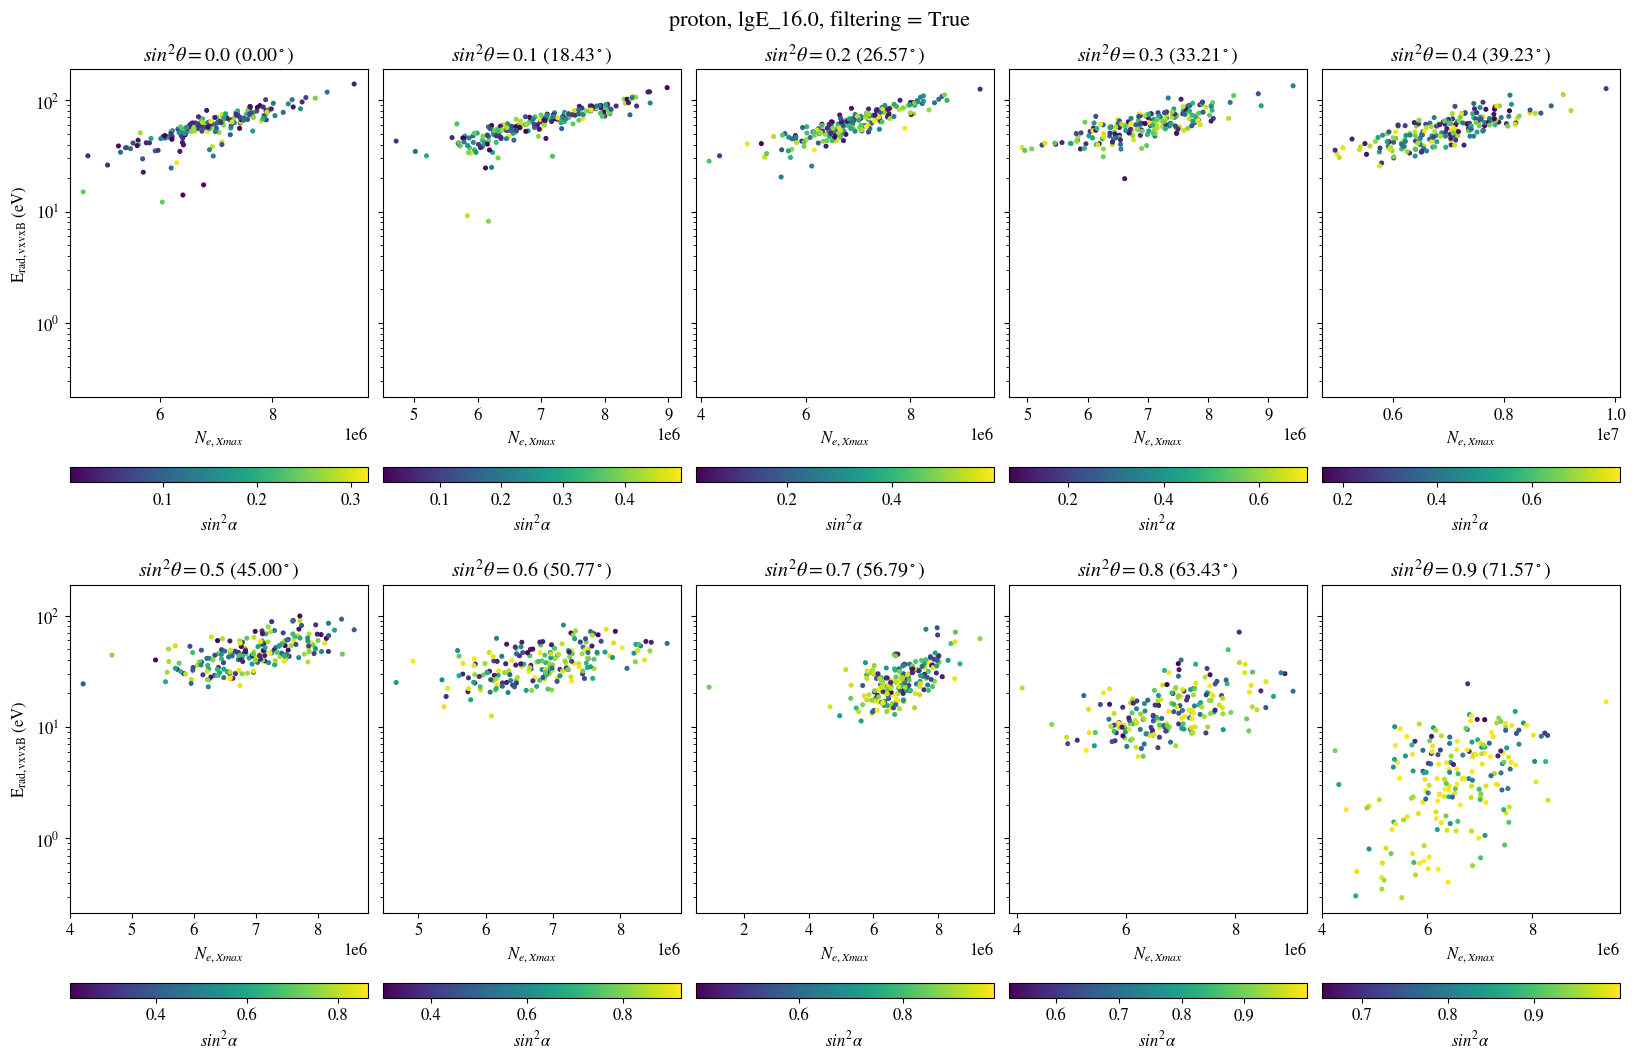

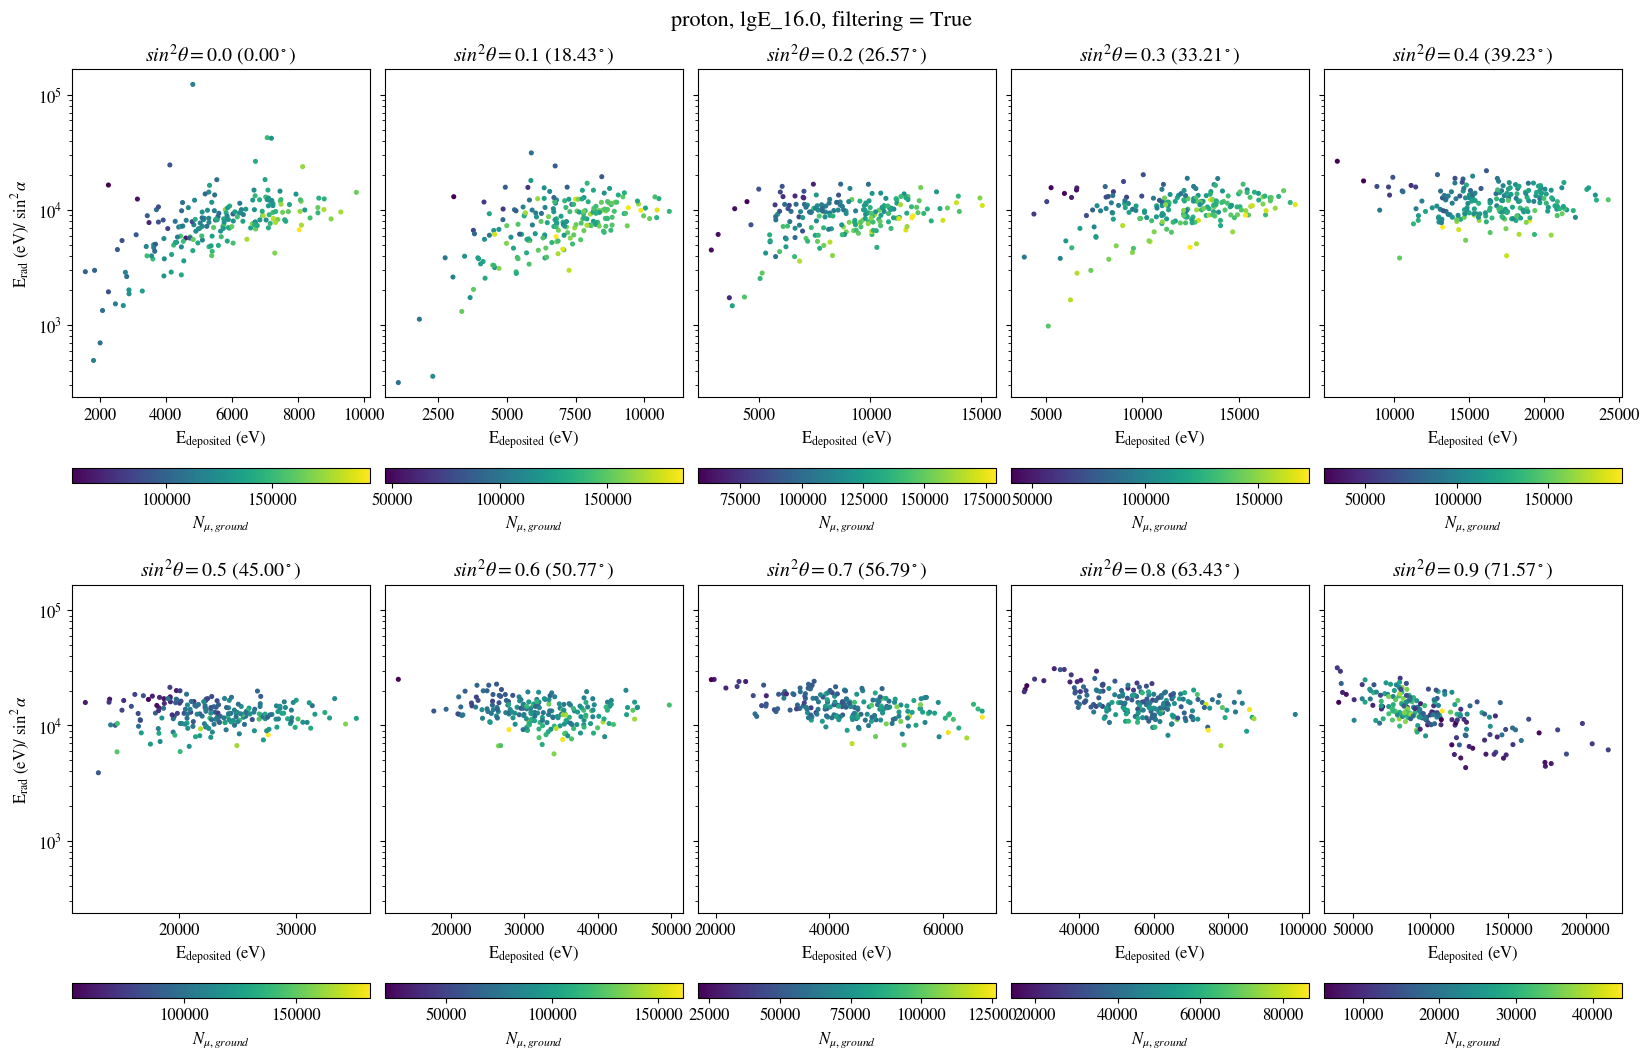

In [11]:
primary = ["proton"]
energy = ['lgE_16.0']
style = 'horiz'
corr =['NeErad', 'NeErad_norm', 'NeXmax', 'EradSina', 'EvxBsina', 'EvxBsina_norm', 'EvxvxBsina', 'EvxvxBNe', 'EradEdep']
# corr = ['NeXmax']
filtering = True
for i in corr:
    pltRadEAllzenith(primary, energy, filtering, style=style, corr=i)

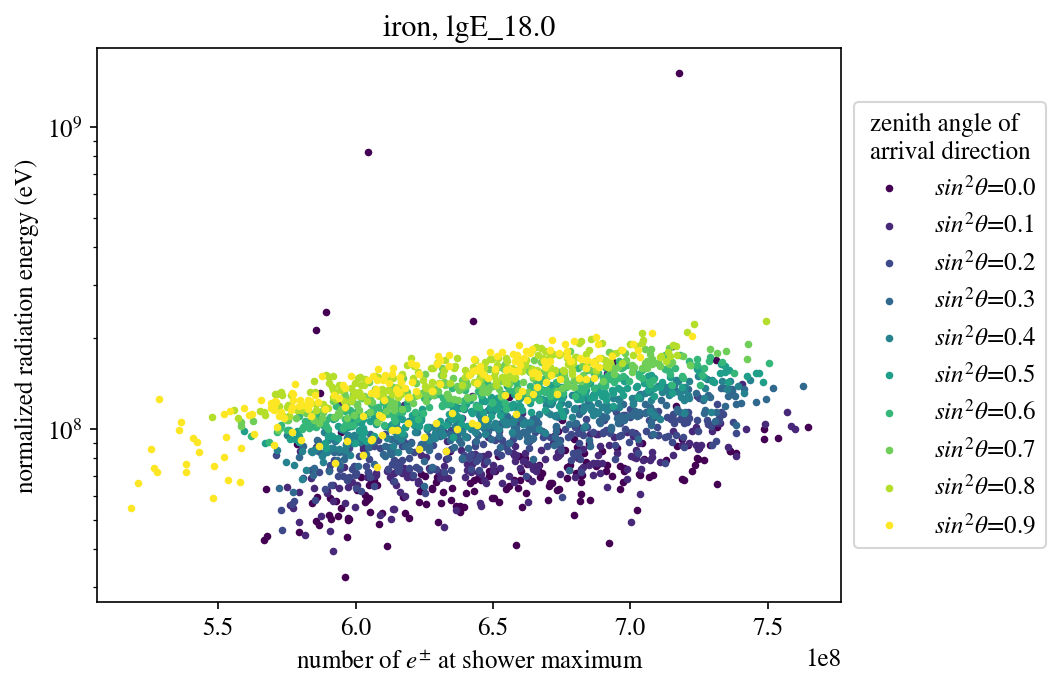

In [12]:
sin2thetas = ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9"]
p = 'iron'
e = 'lgE_18.0'
colors = plt.cm.viridis(np.linspace(0, 1, len(sin2thetas)))
X0 = 697.6

fig, ax = plt.subplots(dpi = 150)

for i, sin2theta in enumerate(sin2thetas):          
    fXmax = fp_Xmax(p, e, sin2theta)
    fRadE = fp_RadE_norm2(p, e, sin2theta)

    fileXmax = np.loadtxt(fXmax)
    Ne = fileXmax[:,5]
    Xmax = fileXmax[:,6]

    

    fileRadE = np.load(fRadE, allow_pickle=True)
    RadE = fileRadE['radE_filtered(eV)']

    alpha = fileRadE['alpha']
    sin2alpha = np.sin(alpha)**2
    thetafloat = float(sin2theta)
    theta = np.arcsin(np.sqrt(thetafloat))
    costheta = np.cos(theta)

    Xv = X0/ costheta


    Ne_filt = []
    RadE_filt = []
    for j in range (len(Xmax)):
        if Xmax[j] <= Xv:
            Ne_filt.append(Ne[j])
            RadE_filt.append(RadE[j])
        else: pass
    ax.scatter(Ne_filt, RadE_filt, s=7, color=colors[i], label=rf'$sin^2 \theta$={sin2theta}')

    # ax.scatter(Ne, RadE, s=7, color=colors[i], label=rf'$sin^2 \theta$={sin2theta}')


ax.set_title(f'{p}, {e}')
ax.set_yscale('log')
# ax.set_ylim(1e3, 1e5)
# ax.set_xlim(0.4e7,1e7)
ax.set_ylabel('normalized radiation energy (eV)')
ax.set_xlabel(r'number of $e^{\pm}$ at shower maximum')

# ax.legend()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='zenith angle of' +'\n'+ 'arrival direction')
plt.show()

# Scintillator Response

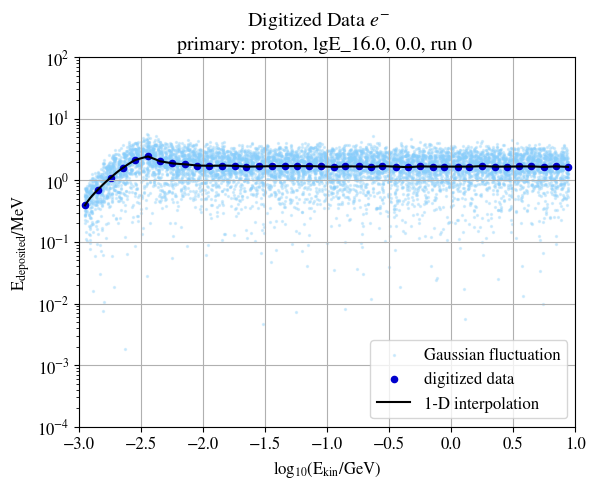

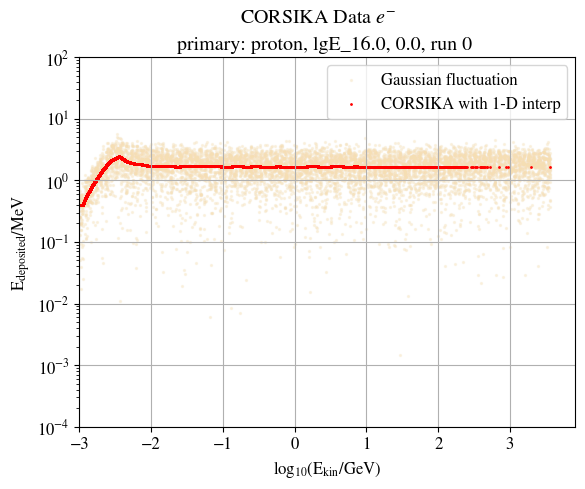

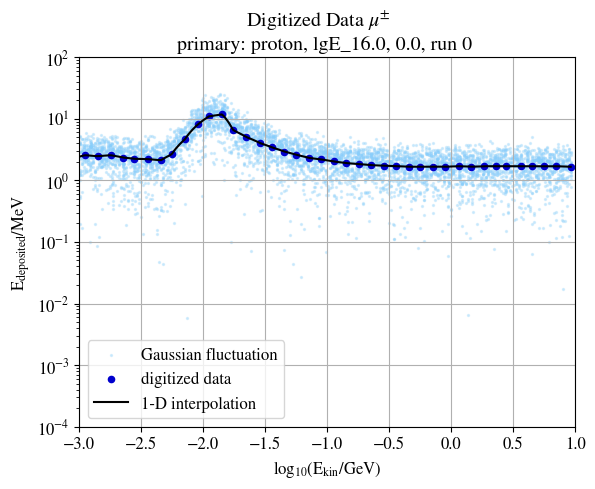

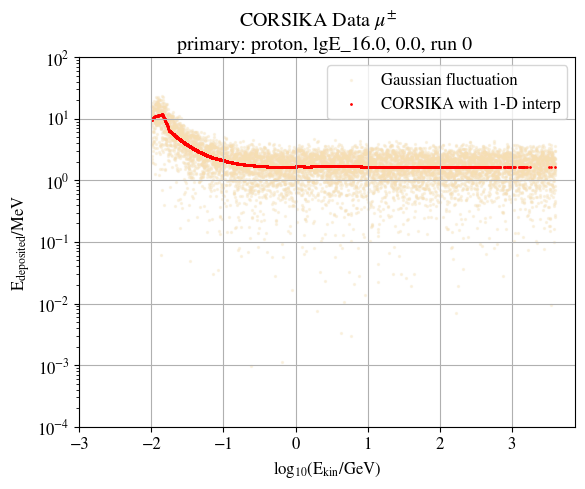

In [13]:
primary = 'proton'
energy = 'lgE_16.0'
sin2theta = '0.0'
run = 0
pltEdepEkin(primary, energy, sin2theta, run)


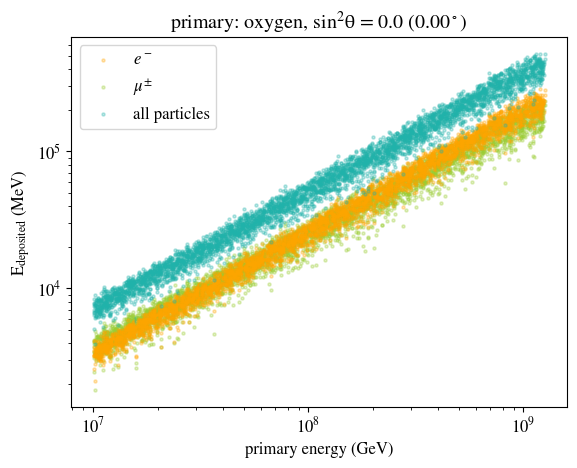

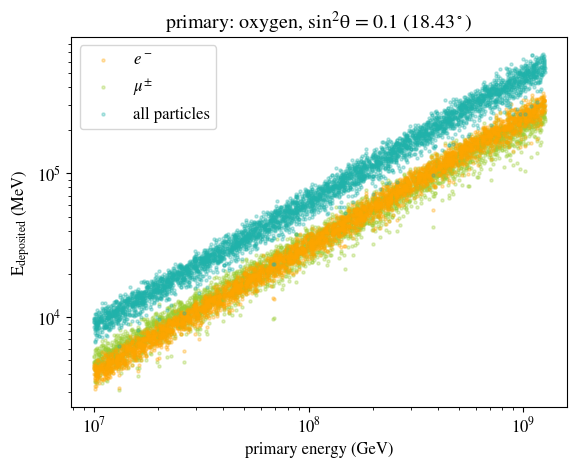

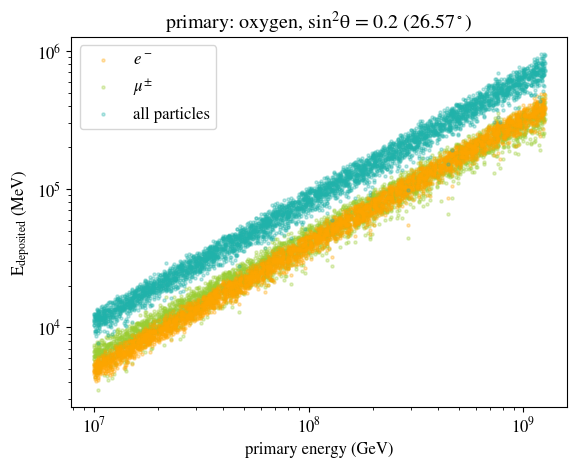

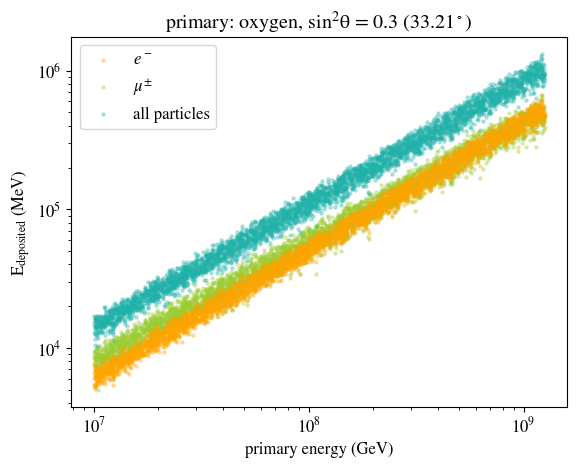

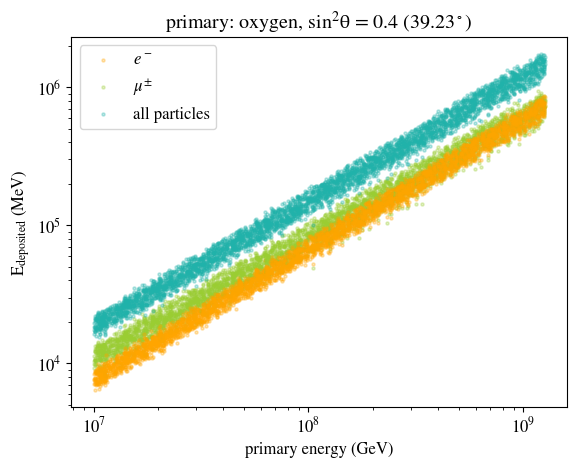

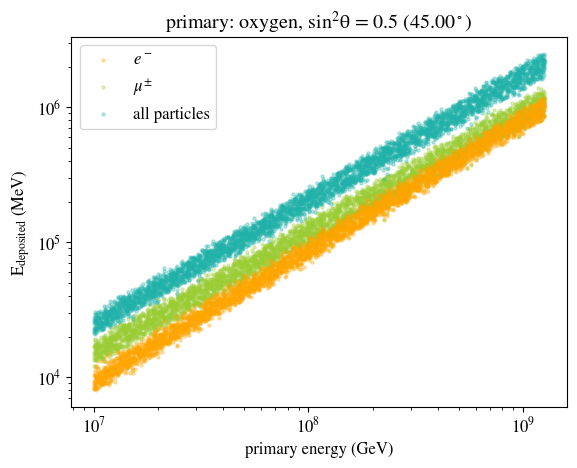

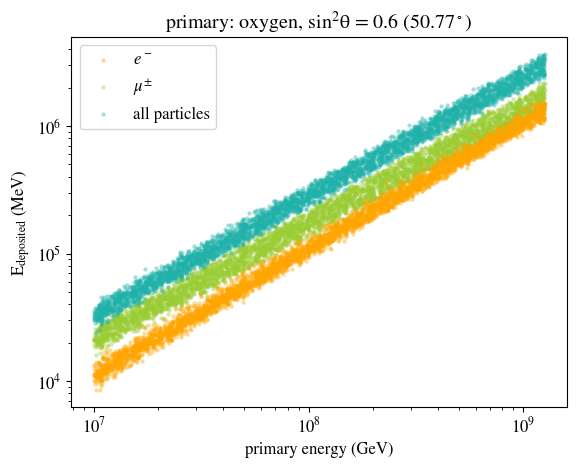

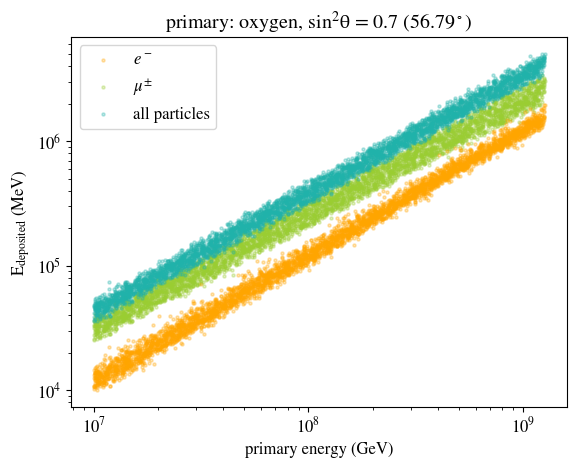

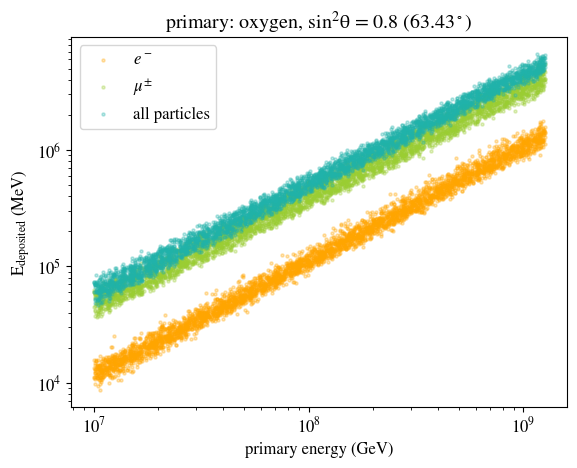

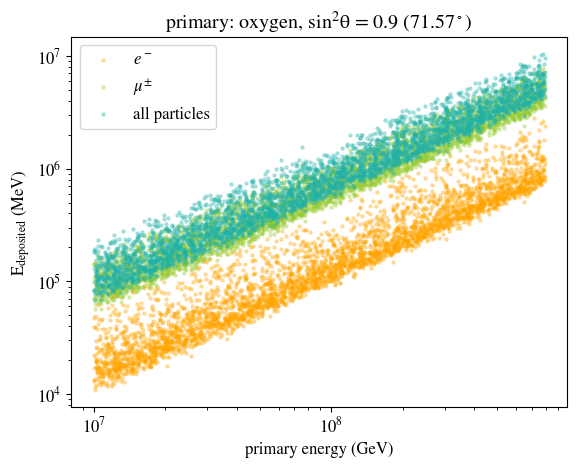

In [14]:

primary = 'oxygen'
threshR = 200
pltEdepEprim(primary, threshR)


In [3]:
# primary = ['iron']
# energy = ['lgE_17.0'] #energy in eV
# style = 'horiz'
# pltRadEAllzenith(primary, energy, filtering = True, style=style, corr='EradEdep')

# Random Forest Regression

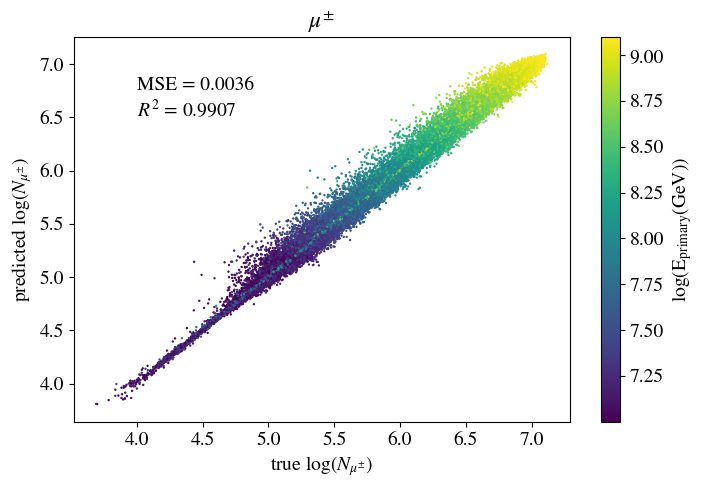

['helium' 'iron' 'oxygen' 'proton']
filtered Xmax with squared error


In [34]:
data_dict = joblib.load("RandomForestRegression/muon_prediction_model_sqerror_filtered.pkl")

model = data_dict["model"]
test_data = data_dict["test_data"]
y_test = test_data["y"]
y_pred = model.predict(test_data["X"])
energy = test_data["energy"]
particle = test_data["particle_id"]
particle_label = test_data['particle_str']
descript = test_data["description"]["description"]

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, s = 0.5, c= energy, cmap="viridis")
plt.xlabel(f'true log($N_{{\mu^{{\pm}}}}$)')
plt.ylabel(f'predicted log($N_{{\mu^{{\pm}}}}$)')
plt.text(4, 6.5, f"MSE = {mse:.4f}" + "\n" + f"$R^2$ = {r2:.4f}")
plt.title(rf'$\mu^{{\pm}}$')
plt.colorbar(label=rf"log($\mathrm{{E_{{primary}} (GeV)}}$)")
plt.show()

print(particle_label)
print(descript)

/tmp/ipykernel_2727963/744499257.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(['particle', 'energy_bin'])['residual'].agg(['mean', 'std']).reset_index()


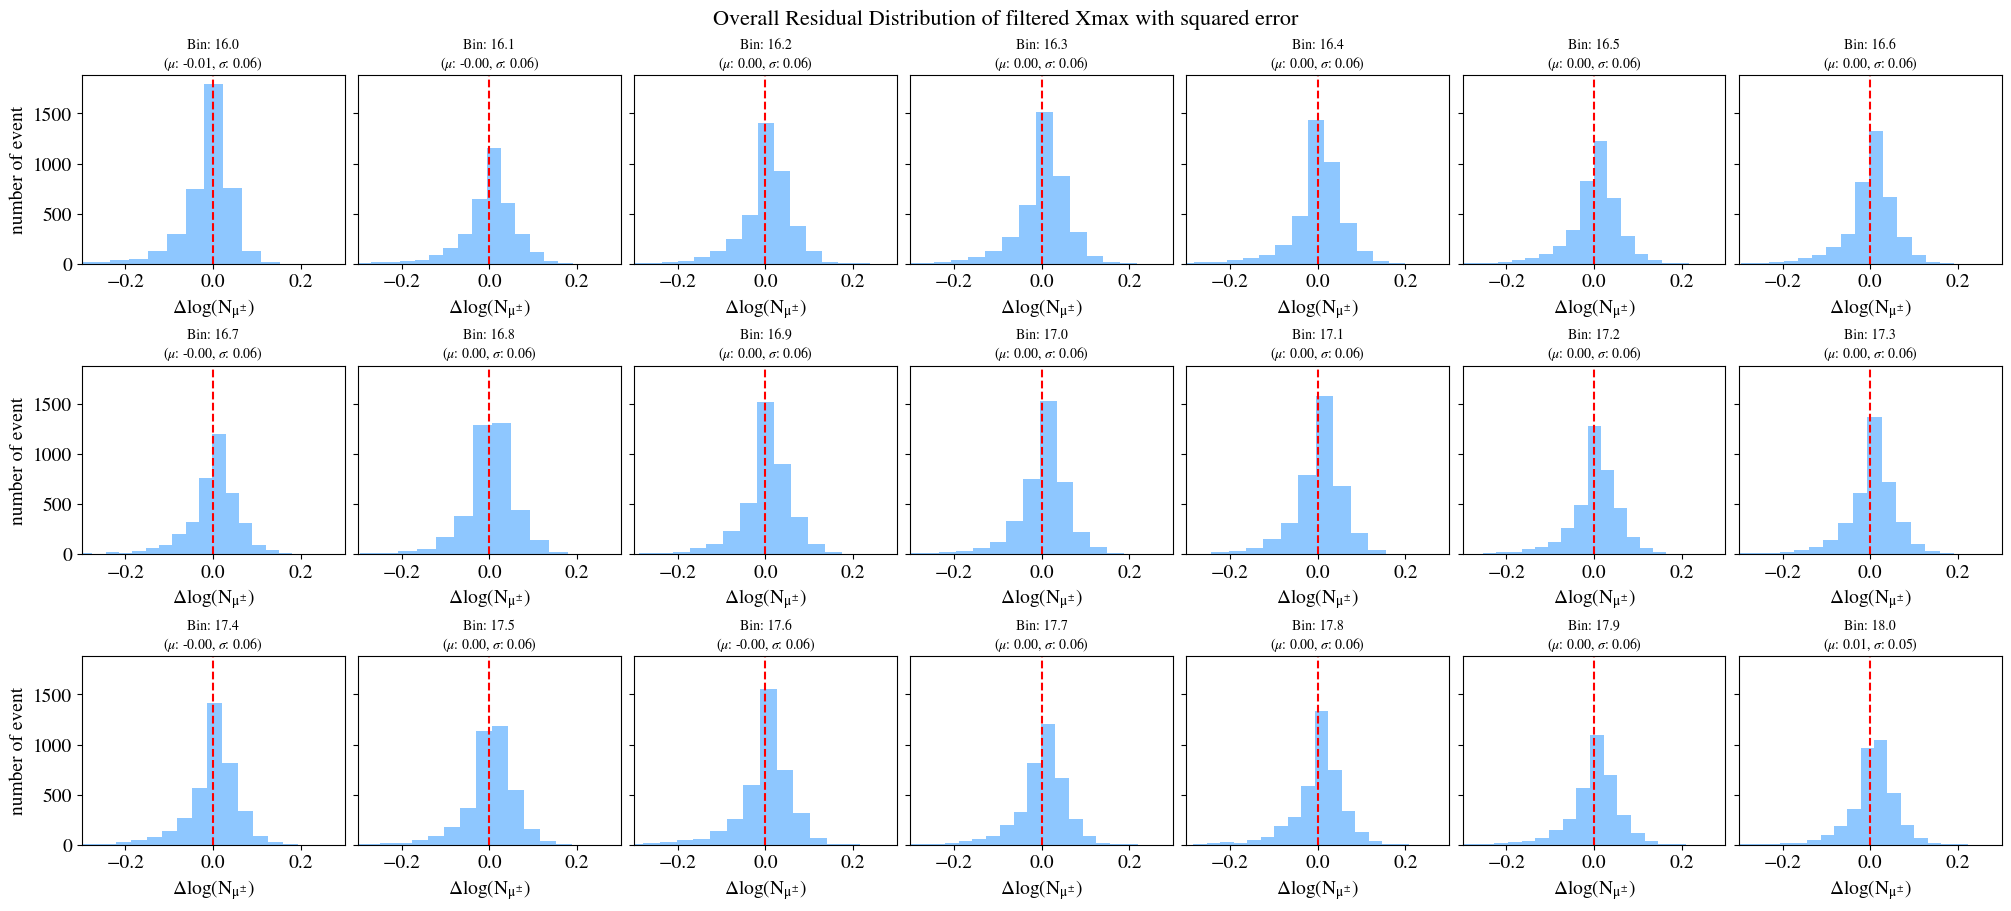

In [36]:
df = pd.DataFrame({'energy': energy}) + 9 # plus 9 because of lg(E(GeV))

# calculate residual
df['y_test'] = y_test
df['y_pred'] = y_pred
df['residual'] = df['y_test'] - df['y_pred']
df['particle'] = particle

# binning
# energy bin 16.0-16.1, 16.1-16.2, ... 18.0-18.1
bins_energy = [x/10 for x in range(160,182)]
labels = [f"{x/10}" for x in range(160,181)]
df['energy_bin'] = pd.cut(df['energy'], bins=bins_energy, labels=labels)
bins_ax = [f"{x/10:.1f}" for x in range(160,181)]
n_bins = len(bins_ax)
# particle bin
bins_particle = df['particle'].sort_values().unique()
summary = df.groupby(['particle', 'energy_bin'])['residual'].agg(['mean', 'std']).reset_index()

cols, rows = 7, 3
fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows), constrained_layout=True, sharey= True)
axes = axes.flatten() # one sequence list
all_mean = []
all_std = []
for i, bin_name in enumerate(bins_ax):
    ax = axes[i]

    # ax.set_aspect('equal')
    subset = df[df['energy_bin'] == bin_name] # select data in each energy bin
    

    ax.hist(subset['residual'], color='dodgerblue', bins=20, alpha = 0.5)
    ax.axvline(0, color='red', linestyle='--', label='Residual = 0')
    
    mean_res = subset['residual'].mean()
    std_res = subset['residual'].std()

    ax.set_title(f"Bin: {bin_name}\n($\mu$: {mean_res:.2f}, $\sigma$: {std_res:.2f})", fontsize=10)
    ax.set_xlabel(rf'$\Delta \mathrm{{log(N_{{\mu^{{\pm}}}})}}$')
    
    ax.set_xlim(-0.3, 0.3)
    
    if i%7 == 0:
        ax.set_ylabel('number of event')
    all_mean.append(mean_res)
    all_std.append(std_res)


plt.suptitle(f'Overall Residual Distribution of {descript}', fontsize=16)
plt.show()



<Figure size 800x500 with 0 Axes>

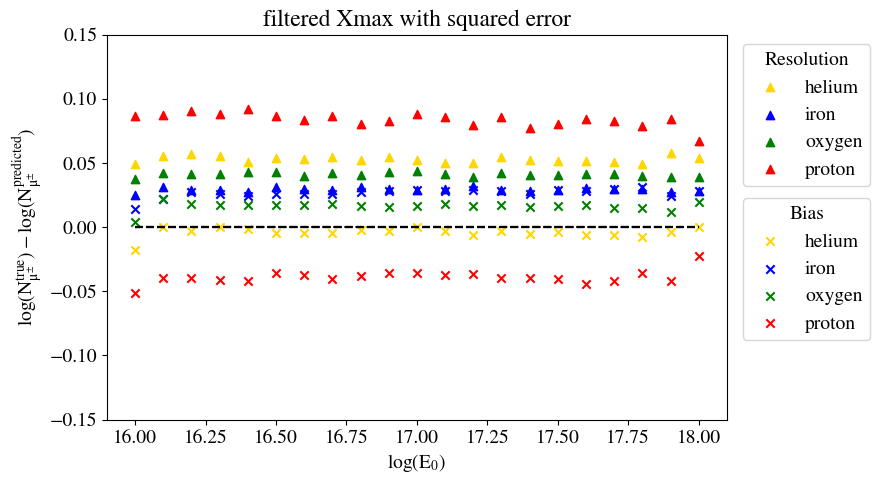

In [37]:
style_bias, style_res = 'x', '^'
colors = ['gold', 'b', 'g', 'r']
fig = plt.figure(figsize=(8, 5))
x_space = np.linspace(16.0, 18.0, num = 21)

fig, ax = plt.subplots(figsize=(8, 5))
handle_res = []
handle_bias  = []
for p in bins_particle: 
    subset = summary[summary['particle'] == p]
    all_mean = subset['mean']
    all_std = subset['std']

    res = ax.scatter(x_space, all_std, label = f'{particle_label[p]}', marker = style_res, color = colors[p])
    bias = ax.scatter(x_space, all_mean, label = f'{particle_label[p]}', marker = style_bias, color = colors[p])

    handle_res.append(res)
    handle_bias.append(bias)

    ax.hlines(y = 0, xmin = min(x_space), xmax = max(x_space), linestyle = '--', color = 'black')
    ax.set_ylim(-0.15, 0.15)
    
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', handles=[handle_res, handle_bias])
leg1 = ax.legend(bbox_to_anchor=(1.01, 1), handles=handle_res, loc='upper left', title="Resolution")
ax.add_artist(leg1) 
ax.legend(bbox_to_anchor=(1.01, 0.6), handles=handle_bias, loc='upper left', title="Bias")
ax.set_xlabel(rf'$\mathrm{{log(E_0)}}$')
ax.set_ylabel(rf'$\mathrm{{log(N_{{\mu^{{\pm}}}}^{{true}}) - log(N_{{\mu^{{\pm}}}}^{{predicted}})}}$')
ax.set_title(f'{descript}')
fig.savefig(f'figure/Bias_Reso_{descript}.png', bbox_inches='tight', dpi=300)

In [5]:
data_dict = joblib.load("RandomForestRegression/muon_prediction_model_sqerror_filtered.pkl")

model = data_dict["model"]
test_data = data_dict["test_data"]
Nmu_test = test_data["y"]
Nmu_pred = model.predict(test_data["X"])
energy = test_data["energy"]
particle = test_data["particle_id"]
particle_label = test_data['particle_str']
descript = test_data["description"]["description"]

costheta = test_data['X']['costheta'] 
sin2theta = np.sin(np.arccos(costheta))**2
zenith_bins = np.linspace(0.0, 0.9, 10)
energy_bins = np.linspace(7.0, 9.0, 21)
zenith_indices = np.digitize(sin2theta, zenith_bins)
energy_indices = np.digitize(energy, energy_bins)

mask_helium = (particle == 0)
mask_iron   = (particle == 1)
mask_oxygen = (particle == 2)
mask_proton = (particle == 3)

Nmu = { 'helium': Nmu_test[mask_helium],
        'iron'  : Nmu_test[mask_iron],
        'oxygen': Nmu_test[mask_oxygen],
        'proton': Nmu_test[mask_proton]
}

Nmu_pred = { 'helium': Nmu_pred[mask_helium],
        'iron'  : Nmu_pred[mask_iron],
        'oxygen': Nmu_pred[mask_oxygen],
        'proton': Nmu_pred[mask_proton]
}

E0 = { 'helium': energy[mask_helium],
        'iron'  : energy[mask_iron],
        'oxygen': energy[mask_oxygen],
        'proton': energy[mask_proton]
}

indices_zenith = { 'helium': zenith_indices[mask_helium],
        'iron'  : zenith_indices[mask_iron],
        'oxygen': zenith_indices[mask_oxygen],
        'proton': zenith_indices[mask_proton]
}

indices_energy = { 'helium': energy_indices[mask_helium],
        'iron'  : energy_indices[mask_iron],
        'oxygen': energy_indices[mask_oxygen],
        'proton': energy_indices[mask_proton]
}

Text(0.5, 0.98, '$\\mathrm{N_{\\mu^{\\pm}}}$ Ratio')

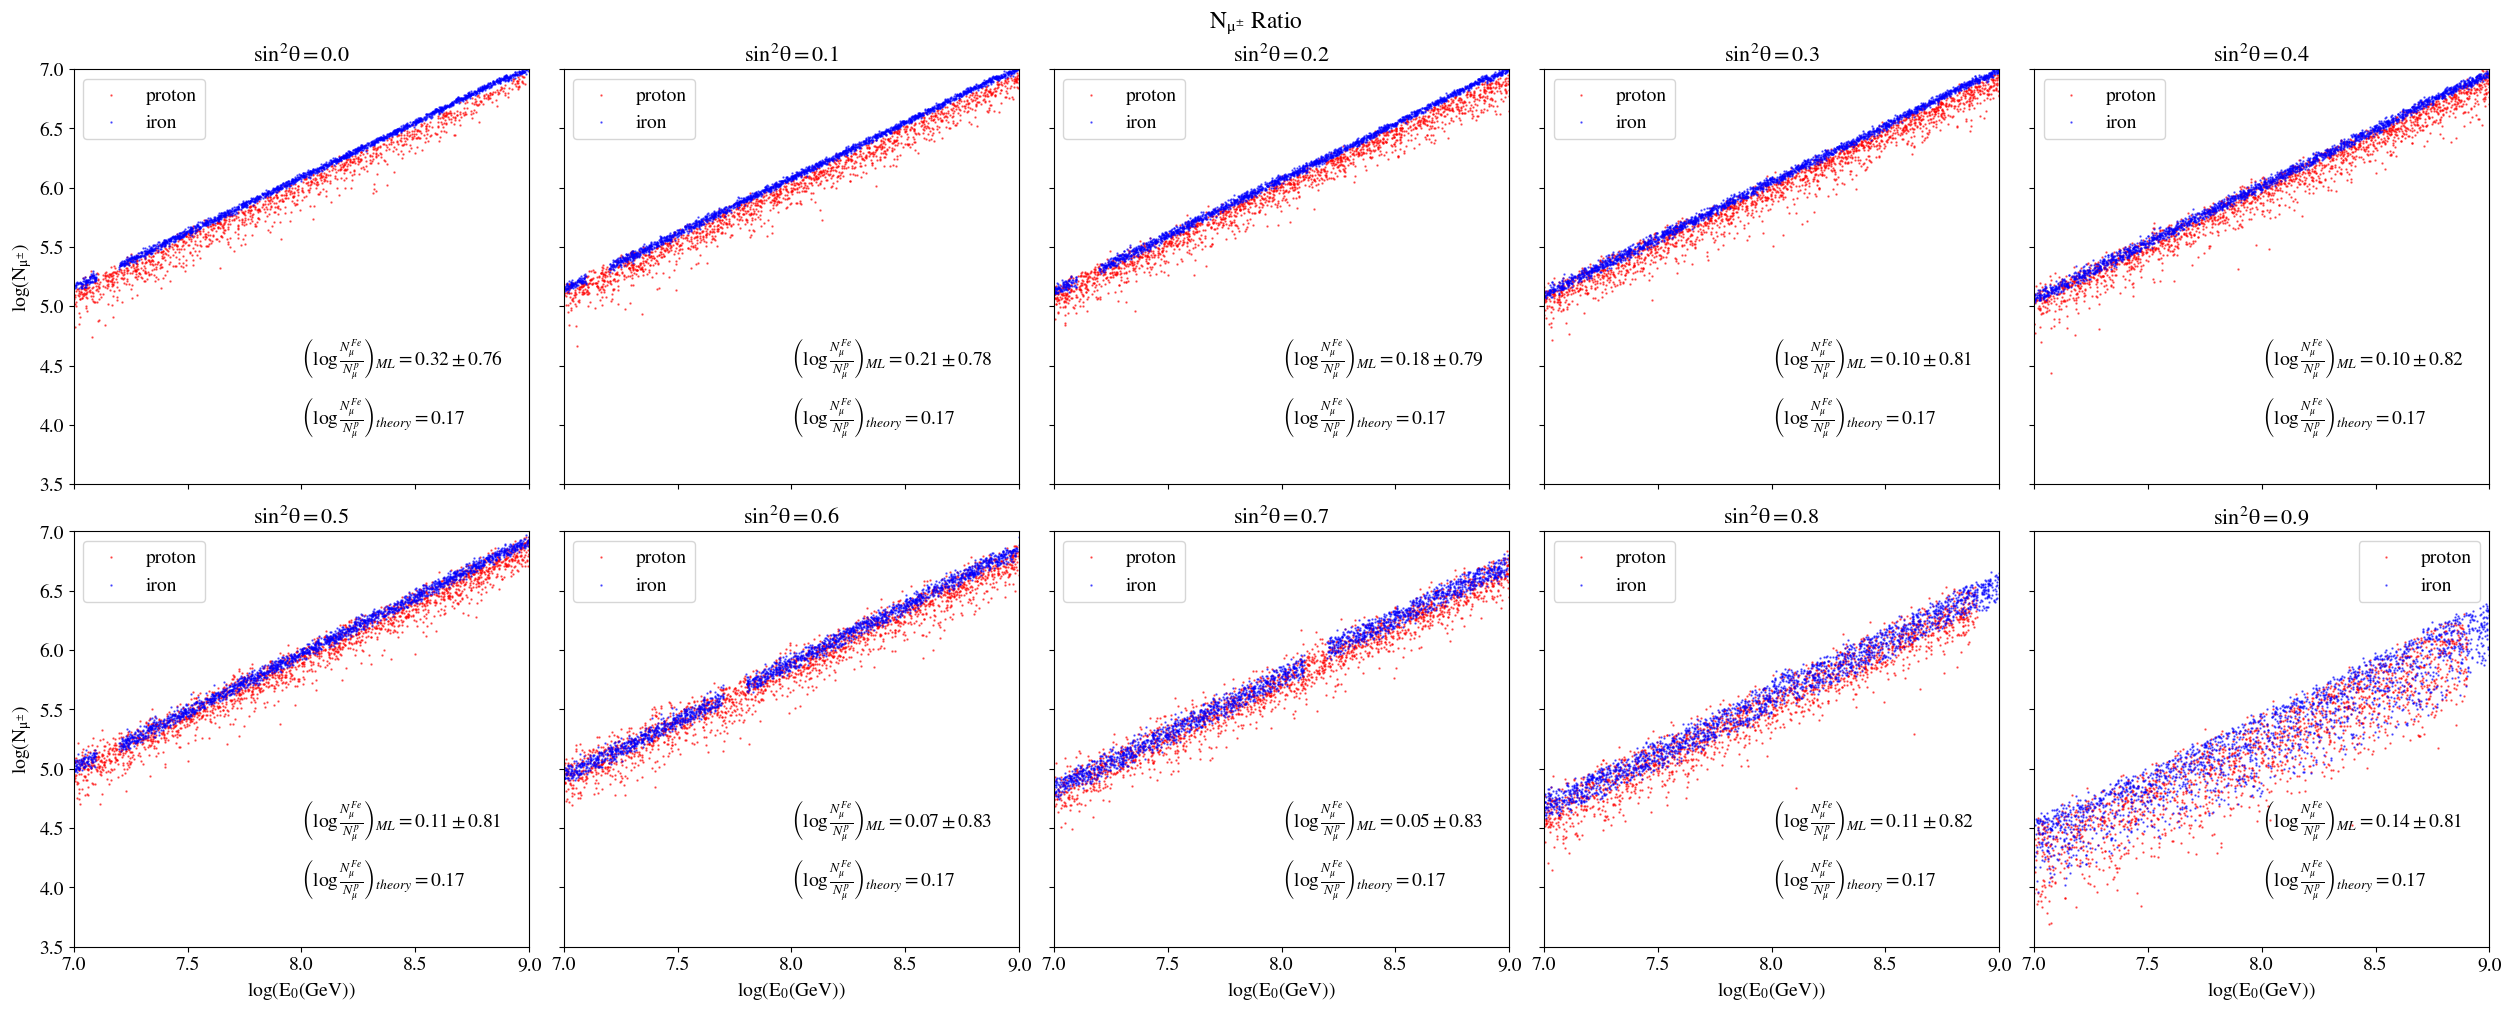

In [6]:
# particles = ['proton', 'helium', 'oxygen', 'iron']
# colors = ['red', 'blue', 'green', 'black']

def Nmu_SuperPosition(A,E,beta):
    return A**(1-beta) * E**beta

Nmu_Fe = Nmu_SuperPosition(56,1,0.9)
Nmu_p = Nmu_SuperPosition(1,1,0.9)
Nmu_ratio = np.log10(Nmu_Fe/Nmu_p)

zenith_bin_number = np.linspace(1,10,num = 10) # 10 zenith bins
energy_bin_number = np.linspace(1,21,num = 21) # 21 energy bins
particles = ['proton', 'iron']
colors = ['red', 'blue']


cols, rows = 5, 2
fig, axes = plt.subplots(rows, cols, figsize=(25, 5 * rows), constrained_layout=True, sharey= True, sharex = True)
axes = axes.flatten() # one sequence list

for zenith in zenith_bin_number:
    Nmu_par = {'proton': [],
           'iron': []}
    axindex = int(zenith)-1
    ax = axes[axindex]

    theta = np.arcsin(np.sqrt((zenith-1)/10))
    costheta = np.cos(theta)
    costheta = 1

    for p in range (len(particles)):
        particle = particles[p]
        bin_mask = (indices_zenith[particle] == zenith)
        x_data = E0[particle][bin_mask]
        y_data = Nmu[particle][bin_mask]
        e_bin_zenith_mask = indices_energy[particle][bin_mask]
        ax.scatter(x_data, y_data, color = colors[p], s = 0.5, alpha = 0.6, label = particle)
        ax.legend()
        Nmu_par[particle].append(y_data)
    
    Nmu_iron = np.array(Nmu_par['iron'])
    Nmu_proton = np.array(Nmu_par['proton'])
    Nmu_diff = np.mean(Nmu_iron) - np.mean(Nmu_proton)
    SD_Nmu_diff =np.sqrt(np.std(Nmu_iron)**2 + np.std(Nmu_proton)**2)
    text_str_ML = r'$\left( \log \frac{{N_{{\mu}}^{{Fe}}}}{{N_{{\mu}}^{{p}}}} \right)_{{ML}} = {0:.2f} \pm {1:.2f}$'.format(Nmu_diff, SD_Nmu_diff)
    text_str_theory = r'$\left( \log \frac{{N_{{\mu}}^{{Fe}}}}{{N_{{\mu}}^{{p}}}} \right)_{{theory}} = {0:.2f}$'.format(Nmu_ratio/costheta)
    ax.text(8, 4.5, text_str_ML)
    ax.text(8, 4.0, text_str_theory)
    ax.set_xlim(7,9)
    ax.set_ylim(3.5,7)
    ax.set_title(rf"$\mathrm{{sin^2{{\theta}} = {(zenith-1)/10} }}$", fontsize=16)
    if axindex >= 5:
        axes[axindex].set_xlabel(r'$\mathrm{{log(E_0 (GeV))}}$')
    if axindex == 0 or axindex == 5:
        axes[axindex].set_ylabel(r'$\mathrm{{log(N_{{\mu^{{\pm}}}})}}$')
plt.suptitle(rf'$\mathrm{{N_{{\mu^{{\pm}}}}}}$ Ratio')

/home/wkammeem/.local/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


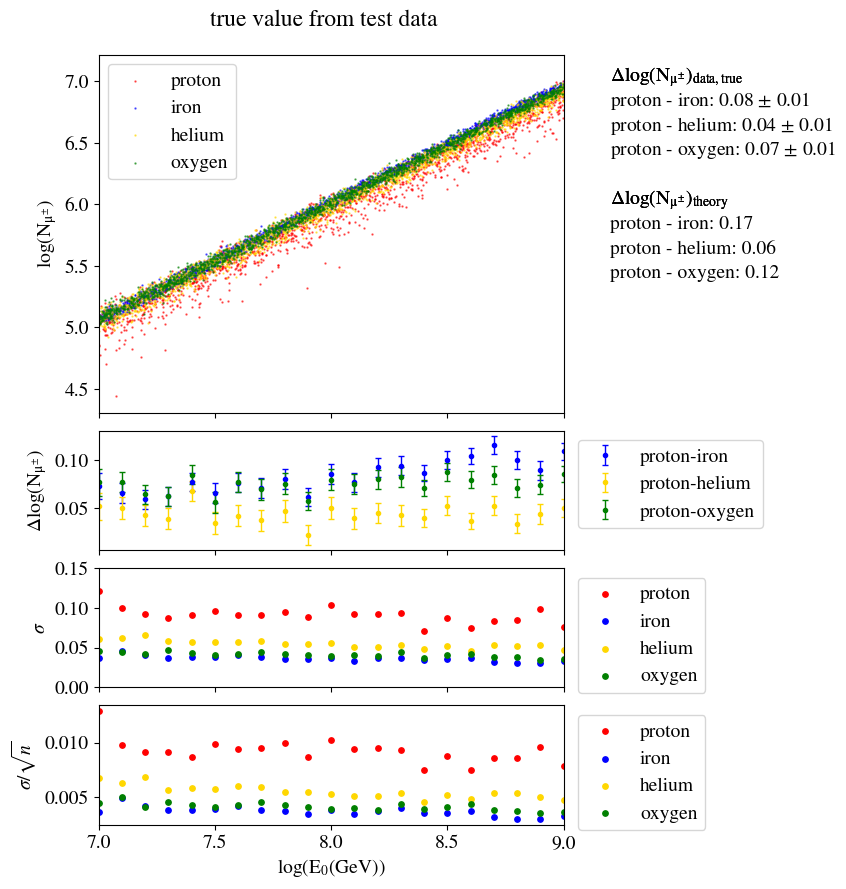

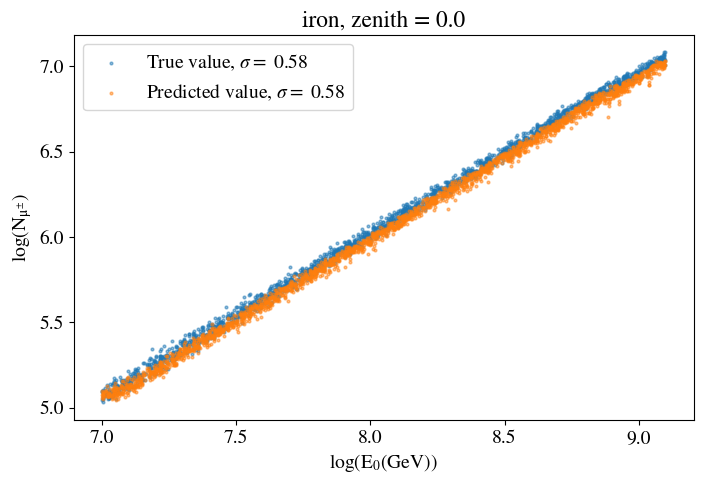

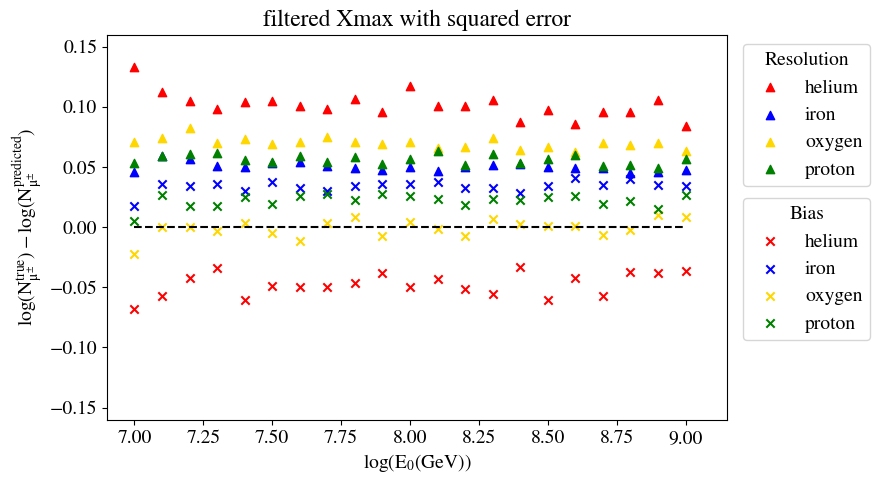

In [7]:
def Nmu_SuperPosition(A,E):
    beta = 0.9
    return A**(1-beta) * E**beta

def NmuDiff(par1, par2): # Calculate mean value and SD for each energy bin
        Nmu_par2 = np.array(Nmu_avg[par2])
        Nmu_par1 = np.array(Nmu_avg[par1])
        par1_SD  = Nmu_SD[par1]
        par2_SD = Nmu_SD[par2]
        N = np.array(Nmu_N[par1])

        Nmu_diff = Nmu_par2 - Nmu_par1
        SD_Nmu_diff =np.sqrt(par2_SD**2 + par1_SD**2)
        SE_Nmu_diff = SD_Nmu_diff/np.sqrt(N)

        # Calculate grand mean and pooled variance for all energy bins
        grand_mean = np.nansum(N * Nmu_diff) / np.nansum(N)
        variances = SE_Nmu_diff**2 
        pooled_variance = np.nansum((N - 1) * variances) / np.nansum(N - 1)
        pooled_sd = np.sqrt(pooled_variance)
        
        return Nmu_diff, SD_Nmu_diff, SE_Nmu_diff, grand_mean, pooled_sd

Nmu_Fe = Nmu_SuperPosition(56,1)
Nmu_p = Nmu_SuperPosition(1,1)
Nmu_ratio = np.log10(Nmu_Fe/Nmu_p)

zenith_bin_number = np.linspace(1,10,num = 10) # 10 zenith bins
energy_bin_number = np.linspace(1,21,num = 21) # 21 energy bins
particles = ['proton', 'iron', 'helium', 'oxygen']

colors = {'proton': 'red',
          'iron': 'blue',
          'helium': 'gold',
          'oxygen': 'green'}
zenith = 5 # vertical shower sin2_0.0 = 1, sin2_0.1 = 2, sin2_0.2 = 3,... 

Nmu_avg = {'proton': [],
        'iron': [],
        'helium': [],
        'oxygen': []}
Nmu_SD = {'proton': [],
        'iron': [],
        'helium': [],
        'oxygen': []}
Nmu_SE = {'proton': [],
        'iron': [],
        'helium': [],
        'oxygen': []}
Nmu_N = {'proton': [],
        'iron': [],
        'helium': [],
        'oxygen': []}

theta = np.arcsin(np.sqrt((zenith-1)/10))
costheta = np.cos(theta)
costheta = 1

cols, rows = 1, 4
fig, (ax0, ax1, ax2, ax3) = plt.subplots(rows, cols, figsize=(6, 10), gridspec_kw={'height_ratios': [3, 1, 1, 1]}, sharex = True)
fig.subplots_adjust(hspace=0.1)

fig2, ax = plt.subplots(figsize=(8, 5))
fig3, ax4 = plt.subplots(figsize=(8, 5))

handle_bias = []
handle_res = []
for p in range (len(particles)):
    particle = particles[p]
    bin_mask = (indices_zenith[particle] == zenith)
    x_data = E0[particle][bin_mask]
    y_data = Nmu[particle][bin_mask]
    y_data_pred = Nmu_pred[particle][bin_mask]
    e_bin_zenith_mask = indices_energy[particle][bin_mask]

    ax0.scatter(x_data, y_data, color = colors[particle], s = 0.5, alpha = 0.6, label = particle)
    ax0.legend()
    
    if particle =='iron': 

         std_true = np.std(y_data)
         std_pred = np.std(y_data_pred)


         ax.scatter(x_data, y_data, s = 4, label = rf'True value, $\sigma = $ {std_true.item():.2f}', alpha = 0.5)
         ax.scatter(x_data, y_data_pred, s = 4, label = rf'Predicted value, $\sigma = $ {std_pred:.2f}', alpha = 0.5)
         ax.legend()
         ax.set_xlabel(r'$\mathrm{{log(E_0 (GeV))}}$')
         ax.set_ylabel(r'$\mathrm{{log(N_{{\mu^{{\pm}}}})}}$')
         ax.set_title('iron, zenith = 0.0')

    bias_all = []
    resolution_all = []    
    for e in energy_bin_number:
        ebin_mask = (e_bin_zenith_mask == e)
        x_data_ebin = x_data[ebin_mask]
        y_data_ebin = y_data[ebin_mask]
        y_data_pred_ebin = y_data_pred[ebin_mask]

        bias = np.mean(y_data_ebin.values - y_data_pred_ebin)
        resolution = np.std(y_data_ebin.values - y_data_pred_ebin)
  
        Nmu_N[particle].append(len(y_data_ebin))
        Nmu_avg[particle].append(np.mean(y_data_ebin))
        Nmu_SD[particle].append(np.std(y_data_ebin))
        bias_all.append(bias)
        resolution_all.append(resolution)
    bias = ax4.scatter(energy_bins, bias_all, color = colors[particle], marker = 'x' , label = f'{particle_label[p]}')
    res = ax4.scatter(energy_bins, resolution_all, color = colors[particle], marker = '^' , label = f'{particle_label[p]}')
    
    handle_res.append(res)
    handle_bias.append(bias)
    
leg1 = ax4.legend(bbox_to_anchor=(1.01, 1), handles= handle_res, loc='upper left', title="Resolution")
ax4.add_artist(leg1) 
ax4.legend(bbox_to_anchor=(1.01, 0.6), handles=handle_bias, loc='upper left', title="Bias")
ax4.set_xlabel(rf'$\mathrm{{log(E_0 (GeV))}}$')
ax4.set_ylabel(rf'$\Delta \mathrm{{log(N_{{\mu^{{\pm}}}})}}$')
ax4.set_ylabel(rf'$\mathrm{{log(N_{{\mu^{{\pm}}}}^{{true}}) - log(N_{{\mu^{{\pm}}}}^{{predicted}})}}$')
ax4.set_title(f'{descript}')
ax4.set_ylim(-0.16,0.16)
ax4.hlines(y= 0, xmin = min(energy_bins), xmax= max(energy_bins), colors = 'k', linestyles =  '--')

for i in particles:
     Nmu_SD[i] = pd.concat(Nmu_SD[i]).values

	
# Calculate Standard Error for ax3 
for i in particles:
     Nmu_SE[i] = Nmu_SD[i]/np.sqrt(Nmu_N[i])


ax0.set_xlim(7,9)
ax0.set_ylabel(r'$\mathrm{{log(N_{{\mu^{{\pm}}}})}}$')

y_ax = [0,0.2,0.4]
compared_par = ['iron', 'helium', 'oxygen']
compared_A = [56, 4, 16]
par_label = ['Fe', 'He', 'O']

for i in range(len(compared_par)):
     par = compared_par[i]
     mean_diff, SD_diff , SE_diff, grand_mean, pooled_sd = NmuDiff('proton',par)
     Nmu_compared = Nmu_SuperPosition(compared_A[i],1)
     Nmu_p = Nmu_SuperPosition(1,1)
     Nmu_ratio = np.log10(Nmu_compared/Nmu_p)
     ax1.errorbar(energy_bins, mean_diff,fmt='o', markersize=3, yerr = SE_diff, linewidth=1, capsize=2, color = colors[par], label = f'proton-{par}')
     text_str_ML = f'proton - {par}: {grand_mean:.2f} $\pm$ {pooled_sd:.2f}'
     text_str_theory = f'proton - {par}: {Nmu_ratio/costheta:.2f}'

     ax0.text(9.2, 7.0, rf'$\mathrm{{\Delta log(N_{{\mu^{{\pm}}}})_{{data,true}} }}$')
     ax0.text(9.2, 6.8 - y_ax[i], text_str_ML)
     ax0.text(9.2, 6.0, rf'$\mathrm{{\Delta log(N_{{\mu^{{\pm}}}})_{{theory}} }}$')
     ax0.text(9.2, 5.8 - y_ax[i], text_str_theory)

ax1.legend(bbox_to_anchor=(1.01, 1),loc='upper left')
ax1.set_ylabel(r'$\mathrm{{\Delta log(N_{{\mu^{{\pm}}}}) }}$')


for i in particles:
        ax2.scatter(energy_bins, Nmu_SD[i], label = i, color = colors[i], s =15)
        ax3.scatter(energy_bins, Nmu_SE[i], label = i, color = colors[i], s =15)

ax2.legend(bbox_to_anchor=(1.01, 1),loc='upper left')
ax2.set_ylabel(rf'$\sigma$')
ax2.set_ylim(0,0.15)

ax3.legend(bbox_to_anchor=(1.01, 1),loc='upper left')
ax3.set_xlabel(r'$\mathrm{{log(E_0 (GeV))}}$')
ax3.set_ylabel(rf'$\sigma / \sqrt{{n}}$')

plt.xlim(6.9, 9.15)
# fig.suptitle(rf'$\mathrm{{N_{{\mu^{{\pm}}}}}}$ Ratio', y = 0.925)
fig.suptitle('true value from test data', y = 0.925)

fig.savefig(f'figure/TrueRegression_{descript}.png', bbox_inches='tight', dpi=300)
# fig3.savefig('figure/Bias_Reso_Regression.png', bbox_inches='tight', dpi=300)

# Brute Force Regression

alpha = -0.0022, beta = 0.2735, gamma = 3.51e-02, b = -1.16e+06, delta = 2.33e+02
alpha = -0.0043, beta = 0.3145, gamma = 3.69e-02, b = -1.23e+06, delta = 2.22e+02
alpha = -0.0074, beta = 0.3570, gamma = 3.51e-02, b = -1.10e+06, delta = 2.00e+02
alpha = -0.0113, beta = 0.3954, gamma = 3.41e-02, b = -1.04e+06, delta = 1.86e+02


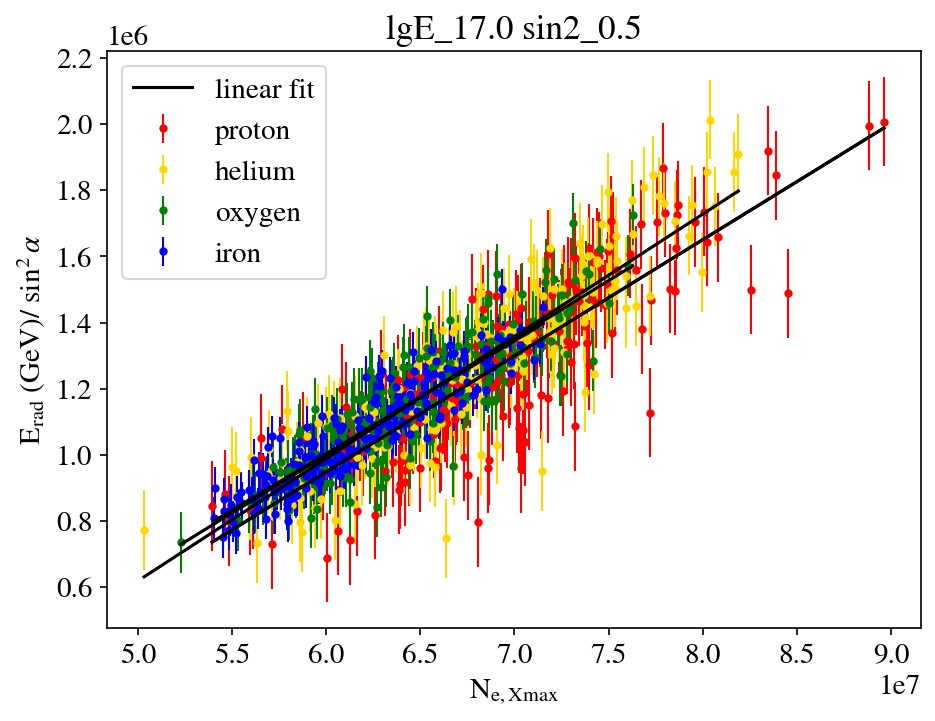

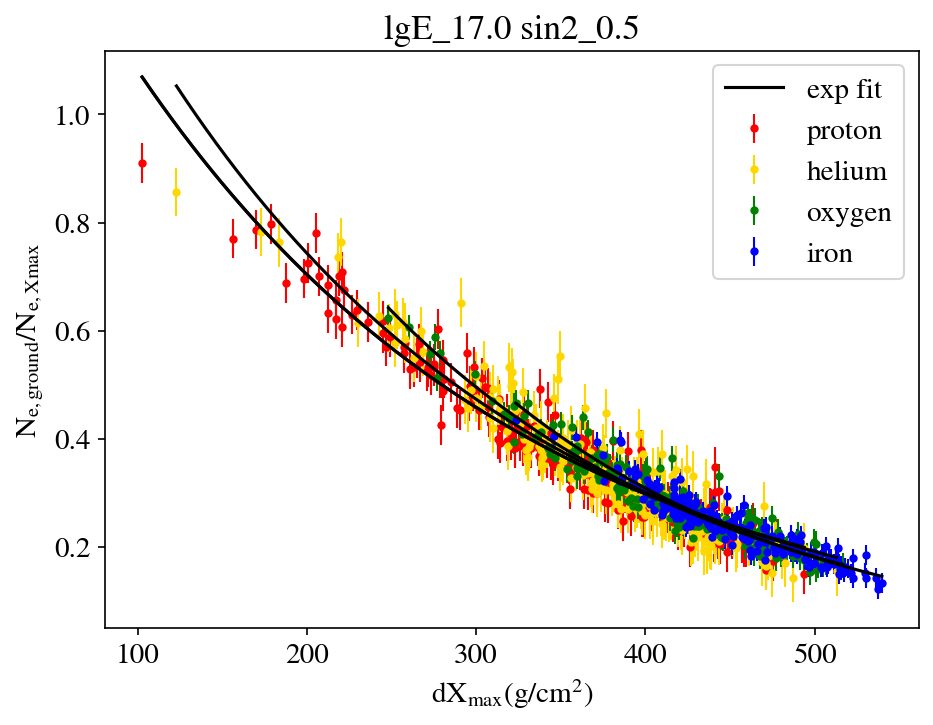

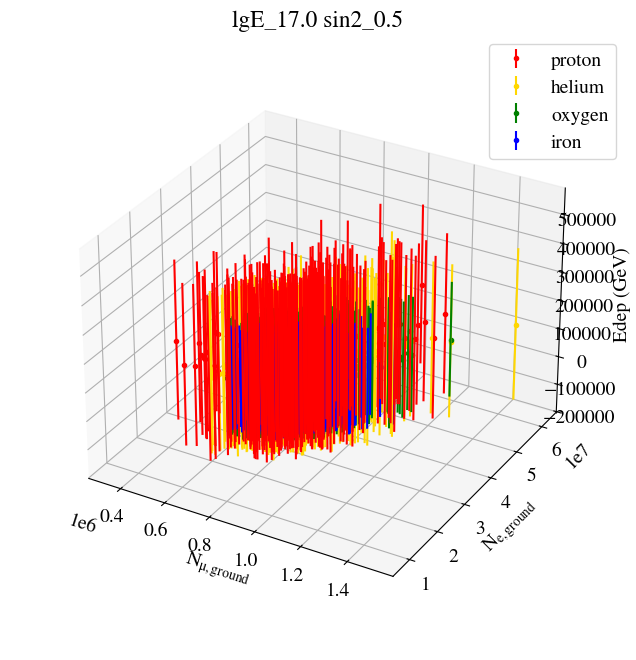

In [3]:
ThreshR = 200
filteringXmax = True
NmuNorm = False
sin2_bin = 0.5
lgE_bin_GeV = 17.0
dataforregression = True # should give the same result from either True/False
particle =['proton', 'helium', 'oxygen', 'iron']
pltSpecificBinFit(sin2_bin, lgE_bin_GeV, particle,filteringXmax,ThreshR,NmuNorm,dataforregression)